In [4]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import boxcox, gaussian_kde
from sklearn.preprocessing import (StandardScaler, MinMaxScaler,
                                   RobustScaler, LabelEncoder, OneHotEncoder)
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor'  : '#FFFFFF',
    'axes.facecolor'    : '#F8F8FF',
    'axes.grid'         : True,
    'grid.alpha'        : 0.35,
    'grid.linestyle'    : '--',
    'font.size'         : 11,
    'axes.titlesize'    : 13,
    'axes.labelsize'    : 11,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
})

print("All libraries imported successfully.")
print(f"   Pandas  : {pd.__version__}")
print(f"   NumPy   : {np.__version__}")
print(f"   Seaborn : {sns.__version__}")

All libraries imported successfully.
   Pandas  : 2.2.2
   NumPy   : 2.0.2
   Seaborn : 0.13.2


In [5]:
df = pd.read_csv('train.csv')

print("DATASET SHAPE:", df.shape)

print("\n── COLUMN INFO ──")
df.info()

print("\n── DESCRIPTIVE STATISTICS ──")
print(df.describe().T.to_string())

numerical_cols   = df.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"\nNumerical  columns : {len(numerical_cols)}")
print(f"Categorical columns: {len(categorical_cols)}")

print("\n── TOP 10 FEATURES CORRELATED WITH SalePrice ──")
top_corr = (df.corr(numeric_only=True)['SalePrice']
              .abs()
              .sort_values(ascending=False)
              .head(10))
print(top_corr.to_string())

DATASET SHAPE: (1460, 81)

── COLUMN INFO ──
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  Overall

In [6]:
print("── Columns with Missing Values ──")
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing.to_string())

print(f"\n── All Categorical Columns ──")
cat_cols_check = df.select_dtypes(include='object').columns.tolist()
for i, c in enumerate(cat_cols_check, 1):
    print(f"  {i:2d}. {c:20s}  unique={df[c].nunique():3d}  nulls={df[c].isna().sum()}")

── Columns with Missing Values ──
PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1

── All Categorical Columns ──
   1. MSZoning              unique=  5  nulls=0
   2. Street                unique=  2  nulls=0
   3. Alley                 unique=  2  nulls=1369
   4. LotShape              unique=  4  nulls=0
   5. LandContour           unique=  4  nulls=0
   6. Utilities             unique=  2  nulls=0
   7. LotConfig             unique=  5  nulls=0
   8. LandSlope             unique=  3  nulls=0
   9. Neighborhood          unique= 25  nulls=0
  10. Condition1            unique=  9  nulls=0
  11. Condition2            unique=  8  nulls=0
  12.

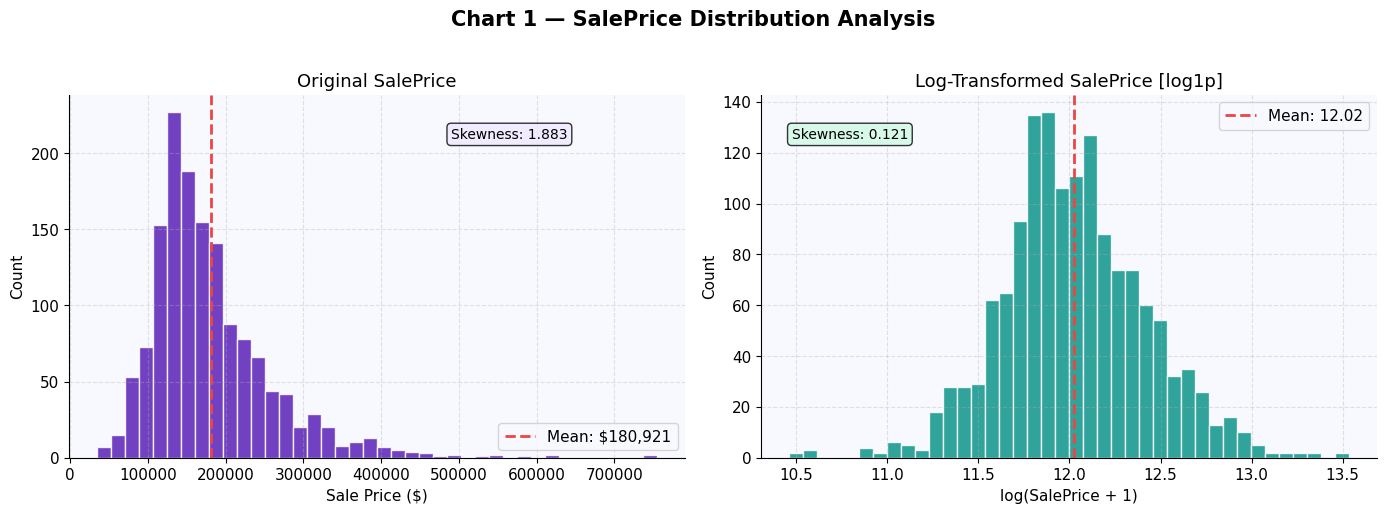

Chart 1 saved.


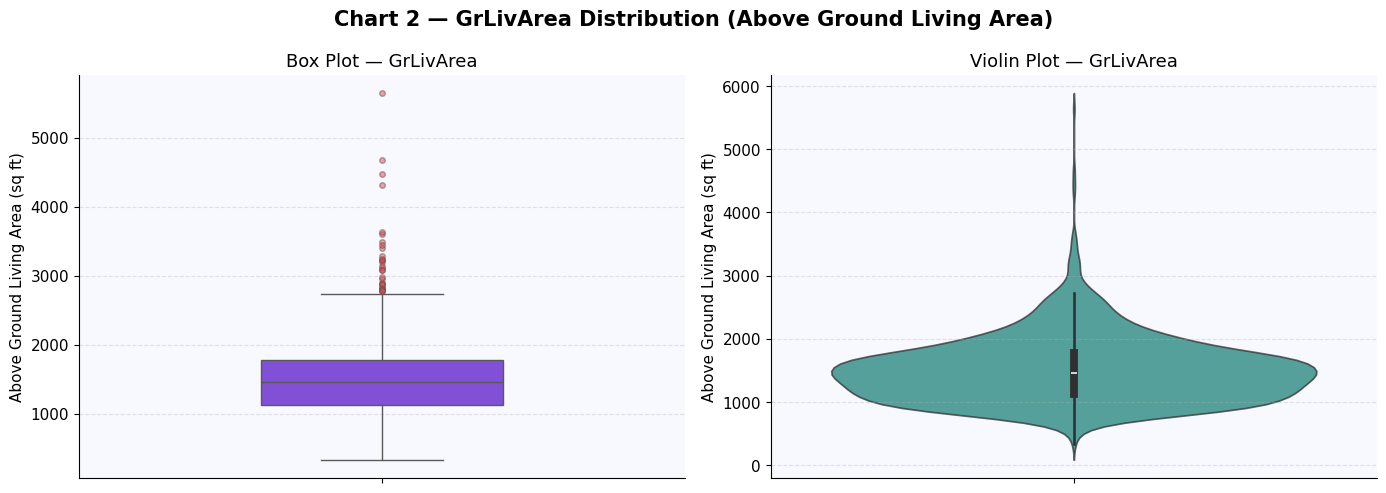

Chart 2 saved.


In [7]:
# ── CHART 1: SalePrice Original vs Log-Transformed ──────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Chart 1 — SalePrice Distribution Analysis',
             fontsize=15, fontweight='bold', y=1.02)

# Left: Original
ax = axes[0]
ax.hist(df['SalePrice'], bins=40, color='#5B21B6',
        edgecolor='white', alpha=0.85)
mean_val = df['SalePrice'].mean()
skew_val = df['SalePrice'].skew()
ax.axvline(mean_val, color='#EF4444', linewidth=2,
           linestyle='--', label=f'Mean: ${mean_val:,.0f}')
ax.set_title('Original SalePrice')
ax.set_xlabel('Sale Price ($)')
ax.set_ylabel('Count')
ax.legend()
ax.annotate(f'Skewness: {skew_val:.3f}',
            xy=(0.62, 0.88), xycoords='axes fraction', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3',
                      facecolor='#EEE8FF', alpha=0.8))

# Right: Log-Transformed
log_price = np.log1p(df['SalePrice'])
ax2 = axes[1]
ax2.hist(log_price, bins=40, color='#0D9488',
         edgecolor='white', alpha=0.85)
mean_log = log_price.mean()
skew_log = log_price.skew()
ax2.axvline(mean_log, color='#EF4444', linewidth=2,
            linestyle='--', label=f'Mean: {mean_log:.2f}')
ax2.set_title('Log-Transformed SalePrice [log1p]')
ax2.set_xlabel('log(SalePrice + 1)')
ax2.set_ylabel('Count')
ax2.legend()
ax2.annotate(f'Skewness: {skew_log:.3f}',
             xy=(0.05, 0.88), xycoords='axes fraction', fontsize=10,
             bbox=dict(boxstyle='round,pad=0.3',
                       facecolor='#D1FAE5', alpha=0.8))

plt.tight_layout()
plt.savefig('w3_chart1_saleprice_dist.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved.")

# ── CHART 2: GrLivArea Box Plot + Violin Plot ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Chart 2 — GrLivArea Distribution (Above Ground Living Area)',
             fontsize=15, fontweight='bold')

sns.boxplot(y=df['GrLivArea'], ax=axes[0], color='#7C3AED', width=0.4,
            flierprops=dict(marker='o', markerfacecolor='#EF4444',
                            markersize=4, alpha=0.5))
axes[0].set_title('Box Plot — GrLivArea')
axes[0].set_ylabel('Above Ground Living Area (sq ft)')

sns.violinplot(y=df['GrLivArea'], ax=axes[1], color='#0D9488',
               inner='box', alpha=0.75)
axes[1].set_title('Violin Plot — GrLivArea')
axes[1].set_ylabel('Above Ground Living Area (sq ft)')

plt.tight_layout()
plt.savefig('w3_chart2_grlivarea_dist.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved.")

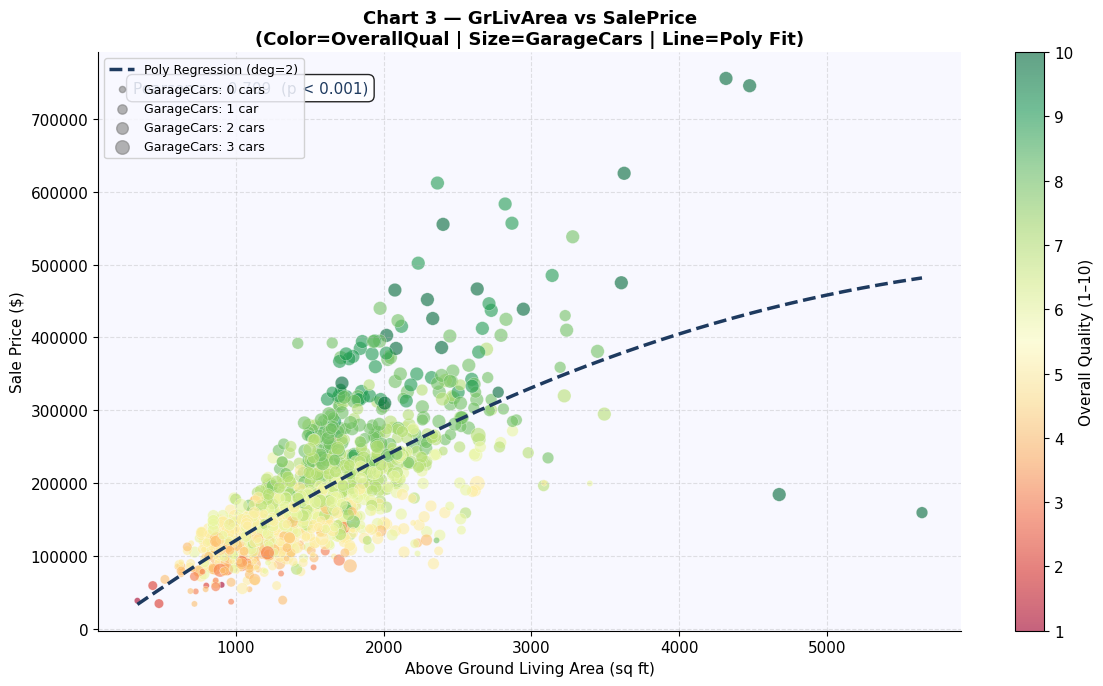

Chart 3 saved.


In [8]:
fig, ax = plt.subplots(figsize=(12, 7))

# Drop rows where any of these 3 columns is null
mask = df[['GrLivArea','SalePrice','OverallQual','GarageCars']].notna().all(axis=1)

scatter = ax.scatter(
    df.loc[mask, 'GrLivArea'],
    df.loc[mask, 'SalePrice'],
    c=df.loc[mask, 'OverallQual'],
    cmap='RdYlGn',
    s=df.loc[mask, 'GarageCars'] * 25 + 20,
    alpha=0.6, edgecolors='white', linewidths=0.3
)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Overall Quality (1–10)', fontsize=11)

# Polynomial regression line degree=2
x_vals = df.loc[mask, 'GrLivArea'].values
y_vals = df.loc[mask, 'SalePrice'].values
coeffs = np.polyfit(x_vals, y_vals, deg=2)
poly   = np.poly1d(coeffs)
x_line = np.linspace(x_vals.min(), x_vals.max(), 300)
ax.plot(x_line, poly(x_line), color='#1E3A5F', linewidth=2.5,
        linestyle='--', label='Poly Regression (deg=2)', zorder=5)

# Pearson correlation
r, p = stats.pearsonr(x_vals, y_vals)
ax.annotate(f'Pearson r = {r:.3f}  (p < 0.001)',
            xy=(0.04, 0.93), xycoords='axes fraction', fontsize=11,
            color='#1E3A5F',
            bbox=dict(boxstyle='round,pad=0.4',
                      facecolor='white', alpha=0.85))

# Manual size legend
for cars, label in [(0,'0 cars'),(1,'1 car'),(2,'2 cars'),(3,'3 cars')]:
    ax.scatter([], [], s=cars*25+20, c='grey', alpha=0.6,
               label=f'GarageCars: {label}')

ax.set_title('Chart 3 — GrLivArea vs SalePrice\n'
             '(Color=OverallQual | Size=GarageCars | Line=Poly Fit)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Above Ground Living Area (sq ft)')
ax.set_ylabel('Sale Price ($)')
ax.legend(loc='upper left', fontsize=9, framealpha=0.85)
plt.tight_layout()
plt.savefig('w3_chart3_scatter_4var.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 saved.")

## Chart 3 — Four-Variable Encoding Explained

This single scatter plot encodes 4 variables simultaneously:
1. X-axis    → GrLivArea (above-ground living area in sq ft)
2. Y-axis    → SalePrice (target variable in $)
3. Color     → OverallQual (1=red/low quality → 10=green/high quality)
4. Point size → GarageCars (larger dot = more garage capacity)

The polynomial regression line (degree=2) captures the non-linear
relationship — price increases accelerate as living area grows.
Pearson r confirms a strong positive linear correlation (~0.71).

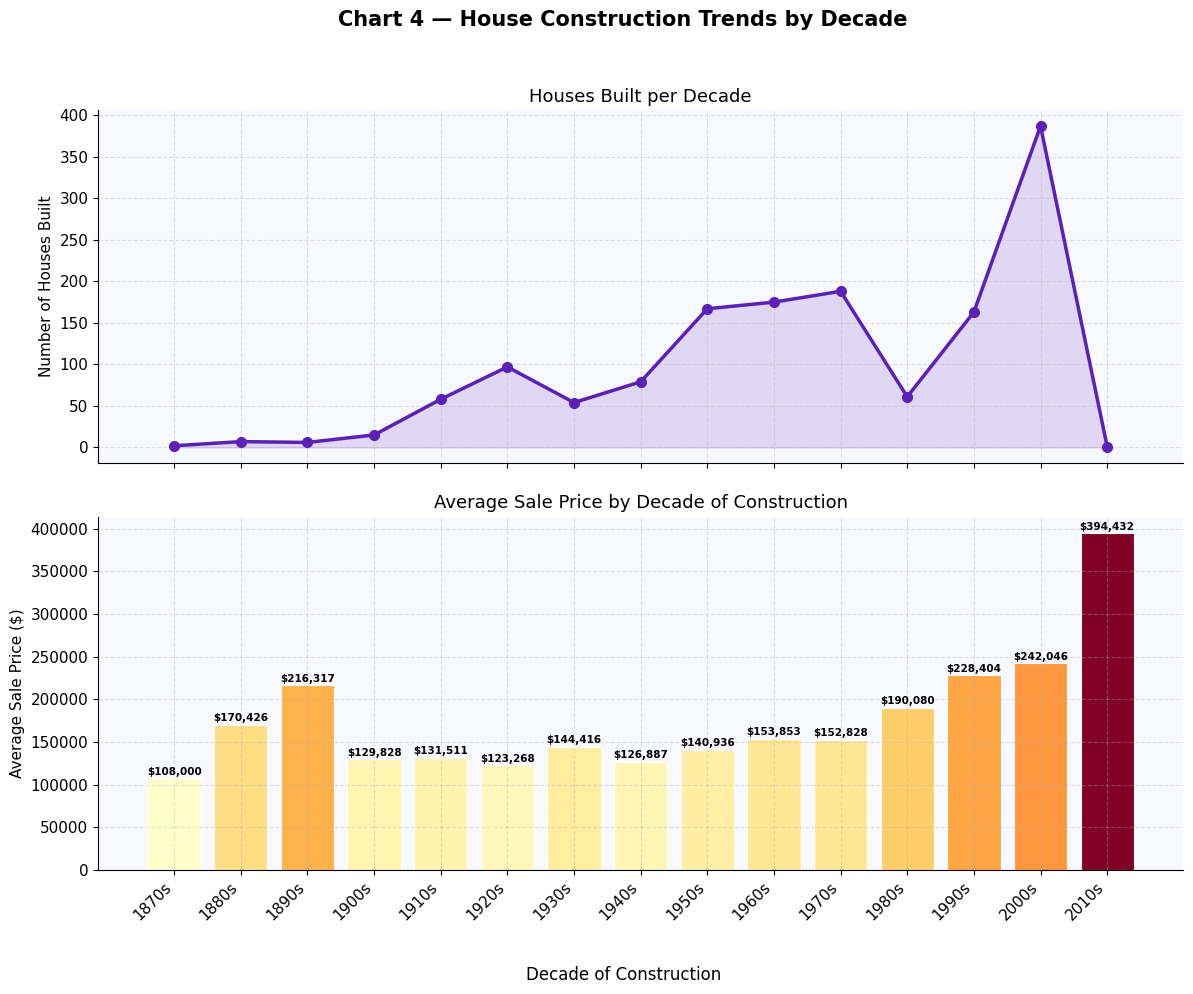

w3_time_trend.png saved.


In [9]:
df_time = df.copy()
df_time['Decade'] = (df_time['YearBuilt'] // 10 * 10).astype(str) + 's'

decade_count = df_time.groupby('Decade').size().reset_index(name='Count')
decade_price = (df_time.groupby('Decade')['SalePrice']
                       .mean()
                       .reset_index(name='AvgPrice'))
decade_df = decade_count.merge(decade_price, on='Decade').sort_values('Decade')

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
fig.suptitle('Chart 4 — House Construction Trends by Decade',
             fontsize=15, fontweight='bold')

# Top: Line chart — count
axes[0].plot(range(len(decade_df)), decade_df['Count'],
             marker='o', color='#5B21B6', linewidth=2.5, markersize=7)
axes[0].fill_between(range(len(decade_df)), decade_df['Count'],
                     alpha=0.15, color='#5B21B6')
axes[0].set_ylabel('Number of Houses Built')
axes[0].set_title('Houses Built per Decade')
axes[0].set_xticks(range(len(decade_df)))
axes[0].set_xticklabels(decade_df['Decade'], rotation=45, ha='right')

# Bottom: Bar chart — avg price with gradient color
norm   = plt.Normalize(decade_df['AvgPrice'].min(),
                       decade_df['AvgPrice'].max())
colors = plt.cm.YlOrRd(norm(decade_df['AvgPrice']))
bars   = axes[1].bar(range(len(decade_df)), decade_df['AvgPrice'],
                     color=colors, edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, decade_df['AvgPrice']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1500,
                 f'${val:,.0f}',
                 ha='center', va='bottom',
                 fontsize=7.5, fontweight='bold')

axes[1].set_ylabel('Average Sale Price ($)')
axes[1].set_title('Average Sale Price by Decade of Construction')
axes[1].set_xticks(range(len(decade_df)))
axes[1].set_xticklabels(decade_df['Decade'], rotation=45, ha='right')

fig.text(0.5, 0.01, 'Decade of Construction', ha='center', fontsize=12)
plt.subplots_adjust(hspace=0.15, bottom=0.12)
plt.savefig('w3_time_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("w3_time_trend.png saved.")

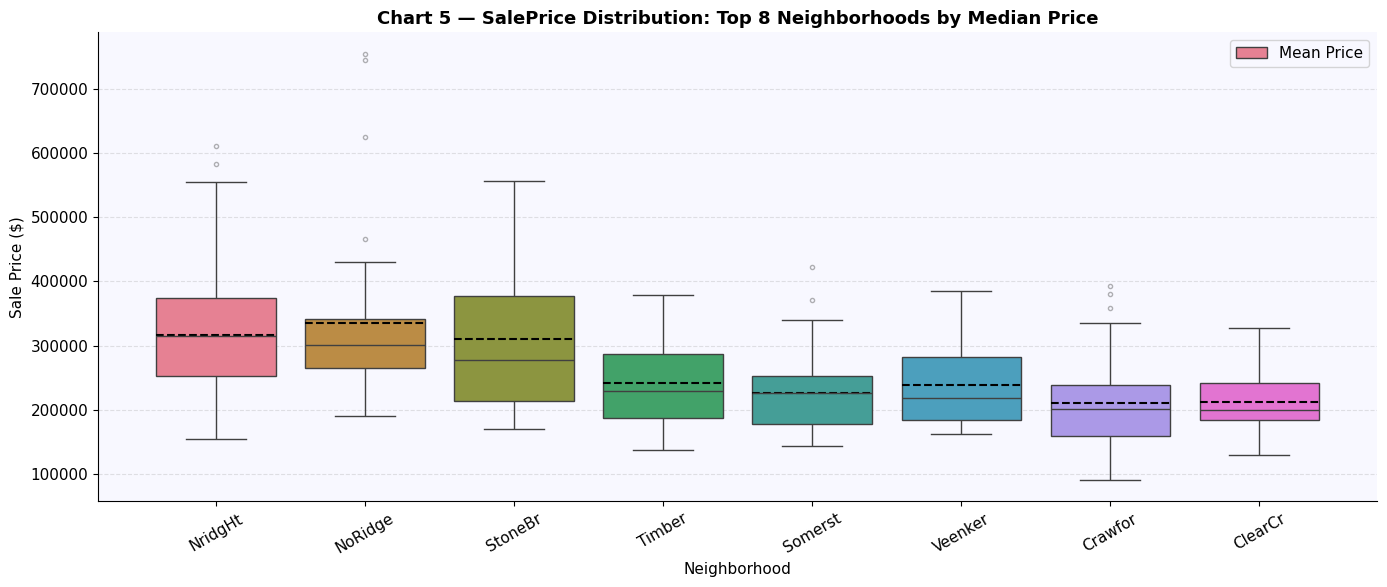

Chart 5 saved.


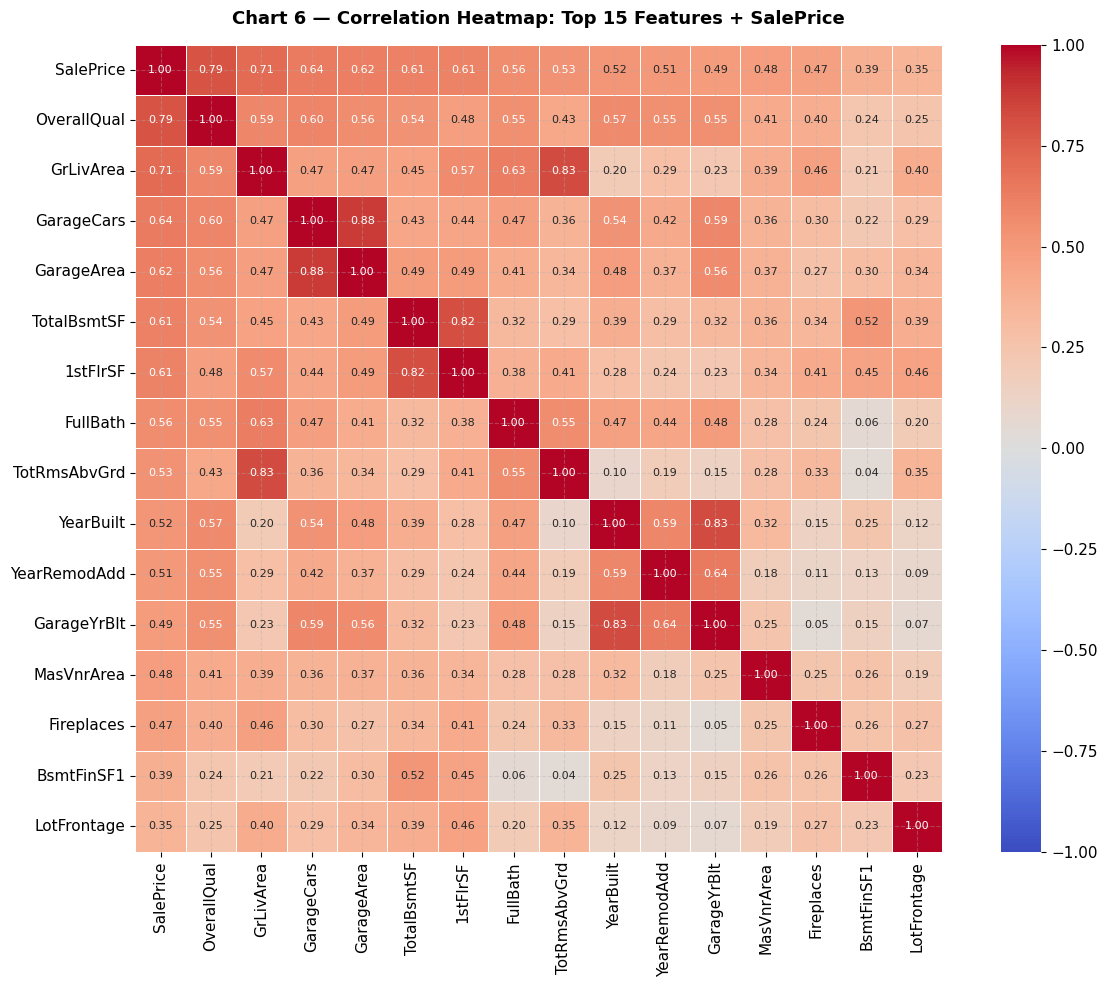

Chart 6 saved.


In [10]:
# ── CHART 5: SalePrice by Top 8 Neighborhoods ───────────────────
top8_neighborhoods = (df.groupby('Neighborhood')['SalePrice']
                        .median()
                        .sort_values(ascending=False)
                        .head(8)
                        .index.tolist())

df_top8 = df[df['Neighborhood'].isin(top8_neighborhoods)].copy()
order8  = (df_top8.groupby('Neighborhood')['SalePrice']
                  .median()
                  .sort_values(ascending=False)
                  .index.tolist())

fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(data=df_top8, x='Neighborhood', y='SalePrice',
            order=order8, palette='husl', ax=ax,
            flierprops=dict(marker='o', markersize=3, alpha=0.4))

for i, nbhd in enumerate(order8):
    mean_p = df_top8.loc[df_top8['Neighborhood']==nbhd, 'SalePrice'].mean()
    ax.hlines(mean_p, i-0.4, i+0.4,
              colors='black', linewidth=1.5, linestyles='--',
              label='Mean' if i==0 else '')

ax.set_title('Chart 5 — SalePrice Distribution: Top 8 Neighborhoods by Median Price',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Neighborhood')
ax.set_ylabel('Sale Price ($)')
ax.tick_params(axis='x', rotation=30)
ax.legend(['Mean Price'], loc='upper right')
plt.tight_layout()
plt.savefig('w3_chart5_neighborhood_box.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 5 saved.")

# ── CHART 6: Correlation Heatmap — Top 15 Numerical Features ────
top16_feats = (df.corr(numeric_only=True)['SalePrice']
                 .abs()
                 .sort_values(ascending=False)
                 .head(16)
                 .index.tolist())

corr_matrix = df[top16_feats].corr()

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, square=True,
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 8}, ax=ax)
ax.set_title('Chart 6 — Correlation Heatmap: Top 15 Features + SalePrice',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('w3_chart6_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 6 saved.")

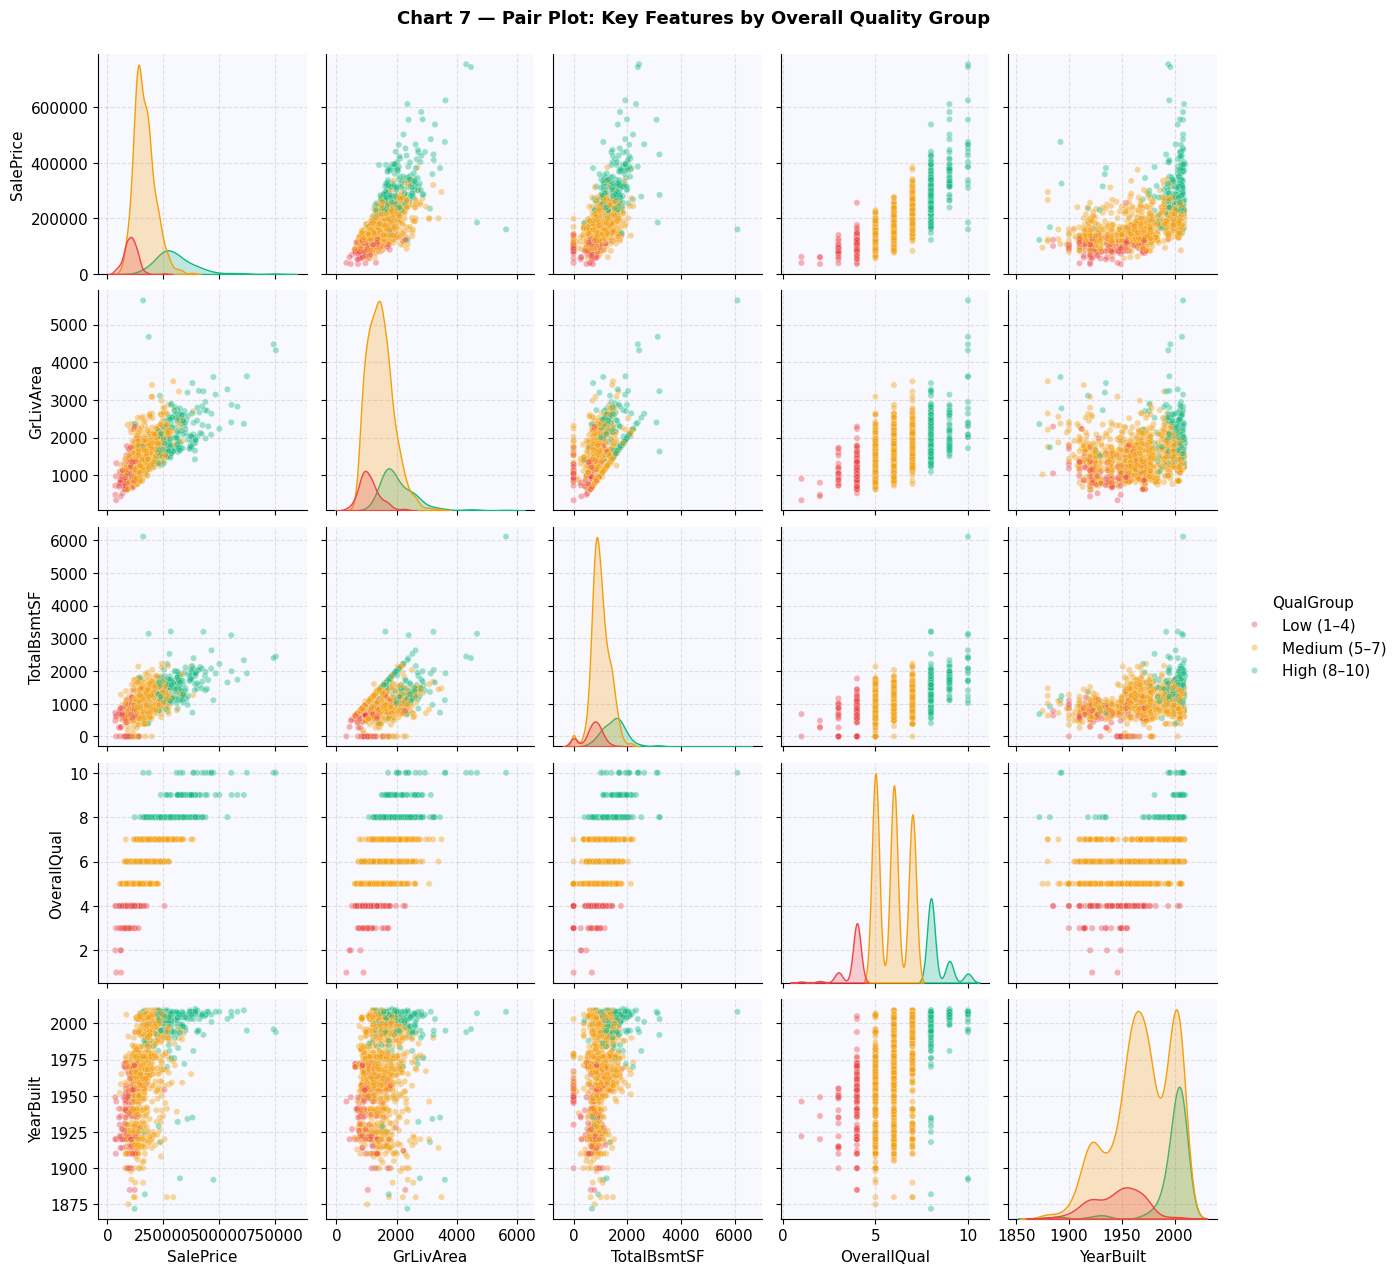

w3_pairplot.png saved.


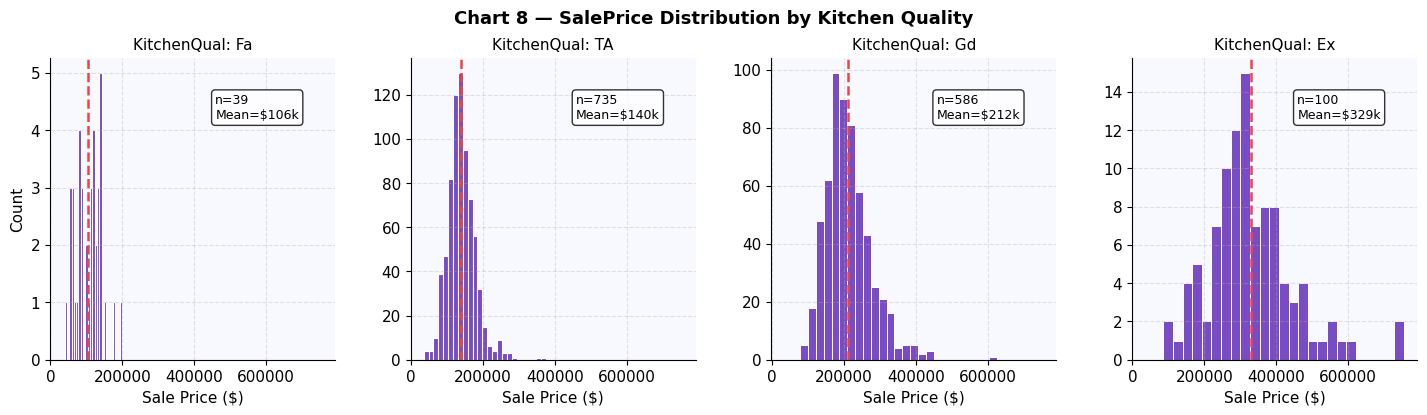

w3_facetgrid.png saved.


In [11]:
# ── CHART 7: Pair Plot ───────────────────────────────────────────
pair_cols = ['SalePrice','GrLivArea','TotalBsmtSF','OverallQual','YearBuilt']

df['QualGroup'] = pd.cut(
    df['OverallQual'],
    bins=[0, 4, 7, 10],
    labels=['Low (1–4)', 'Medium (5–7)', 'High (8–10)']
)

pair_df = df[pair_cols + ['QualGroup']].dropna()

g = sns.pairplot(
    pair_df, hue='QualGroup', vars=pair_cols,
    diag_kind='kde',
    plot_kws=dict(alpha=0.4, s=20),
    palette={
        'Low (1–4)'   : '#EF4444',
        'Medium (5–7)': '#F59E0B',
        'High (8–10)' : '#10B981'
    }
)
g.fig.suptitle('Chart 7 — Pair Plot: Key Features by Overall Quality Group',
               y=1.02, fontsize=13, fontweight='bold')
g.fig.savefig('w3_pairplot.png', dpi=150, bbox_inches='tight')
plt.show()
print("w3_pairplot.png saved.")

# ── CHART 8: FacetGrid — SalePrice by KitchenQual ───────────────
df_kitchen   = df[['SalePrice','KitchenQual']].dropna()
qual_order   = ['Po','Fa','TA','Gd','Ex']
qual_present = [q for q in qual_order
                if q in df_kitchen['KitchenQual'].unique()]

g2 = sns.FacetGrid(df_kitchen, col='KitchenQual',
                   col_order=qual_present,
                   height=4, aspect=0.9, sharey=False)
g2.map(sns.histplot, 'SalePrice', bins=25,
       color='#5B21B6', edgecolor='white', alpha=0.8)

for ax, qual in zip(g2.axes.flat, qual_present):
    subset = df_kitchen.loc[df_kitchen['KitchenQual']==qual, 'SalePrice']
    ax.axvline(subset.mean(), color='#EF4444',
               linewidth=1.8, linestyle='--')
    ax.annotate(
        f'n={len(subset)}\nMean=${subset.mean()/1000:.0f}k',
        xy=(0.58, 0.80), xycoords='axes fraction', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
    )

g2.set_titles(col_template='KitchenQual: {col_name}')
g2.set_axis_labels('Sale Price ($)', 'Count')
g2.fig.suptitle('Chart 8 — SalePrice Distribution by Kitchen Quality',
                y=1.03, fontsize=13, fontweight='bold')
g2.fig.savefig('w3_facetgrid.png', dpi=150, bbox_inches='tight')
plt.show()
print("w3_facetgrid.png saved.")

In [12]:
df_eng = df.copy()

# Fix known missing values before feature creation
df_eng['TotalBsmtSF']  = df_eng['TotalBsmtSF'].fillna(0)
df_eng['BsmtFullBath'] = df_eng['BsmtFullBath'].fillna(0)
df_eng['BsmtHalfBath'] = df_eng['BsmtHalfBath'].fillna(0)
df_eng['MasVnrArea']   = df_eng['MasVnrArea'].fillna(0)
df_eng['GarageYrBlt']  = df_eng['GarageYrBlt'].fillna(0)
df_eng['LotFrontage']  = df_eng['LotFrontage'].fillna(df_eng['LotFrontage'].median())
df_eng['1stFlrSF']     = df_eng['1stFlrSF'].fillna(0)
df_eng['2ndFlrSF']     = df_eng['2ndFlrSF'].fillna(0)
df_eng['FullBath']     = df_eng['FullBath'].fillna(0)
df_eng['HalfBath']     = df_eng['HalfBath'].fillna(0)

# (a) Total square footage — buyers care about total usable space
df_eng['TotalSF'] = (df_eng['TotalBsmtSF'] +
                     df_eng['1stFlrSF'] +
                     df_eng['2ndFlrSF'])

# (b) Weighted bath count — full baths worth more than half baths
df_eng['TotalBaths'] = (df_eng['FullBath'] +
                        0.5 * df_eng['HalfBath'] +
                        df_eng['BsmtFullBath'] +
                        0.5 * df_eng['BsmtHalfBath'])

# (c) House age at sale — older homes typically depreciate in value
df_eng['HouseAge'] = df_eng['YrSold'] - df_eng['YearBuilt']

# (d) Years since last remodel — freshness indicator for buyers
df_eng['RemodelAge'] = df_eng['YrSold'] - df_eng['YearRemodAdd']

# (e) Binary flag — was the house ever remodeled at all?
df_eng['HasRemodeled'] = (
    df_eng['YearBuilt'] != df_eng['YearRemodAdd']
).astype(int)

# (f) Interaction: quality × condition — both must be high for max value
df_eng['QualCond'] = df_eng['OverallQual'] * df_eng['OverallCond']

# (g) Price per square foot — density metric, only where TotalSF > 0
df_eng['PricePerSF'] = np.where(
    df_eng['TotalSF'] > 0,
    df_eng['SalePrice'] / df_eng['TotalSF'],
    np.nan
)

# (h) Is this a new house — built within 5 years of sale date?
df_eng['IsNewHouse'] = (
    df_eng['YearBuilt'] >= df_eng['YrSold'] - 5
).astype(int)

new_features = ['TotalSF','TotalBaths','HouseAge','RemodelAge',
                'HasRemodeled','QualCond','PricePerSF','IsNewHouse']

print("── Engineered Feature Statistics ──")
print(df_eng[new_features].describe().T.to_string())
print("\n── First 10 Rows of Engineered Features ──")
print(df_eng[new_features].head(10).to_string())

── Engineered Feature Statistics ──
               count         mean         std         min          25%          50%          75%          max
TotalSF       1460.0  2567.048630  821.714421  334.000000  2009.500000  2474.000000  3004.000000  11752.00000
TotalBaths    1460.0     2.210616    0.785399    1.000000     2.000000     2.000000     2.500000      6.00000
HouseAge      1460.0    36.547945   30.250152    0.000000     8.000000    35.000000    54.000000    136.00000
RemodelAge    1460.0    22.950000   20.640653   -1.000000     4.000000    14.000000    41.000000     60.00000
HasRemodeled  1460.0     0.476712    0.499629    0.000000     0.000000     0.000000     1.000000      1.00000
QualCond      1460.0    33.864384    9.219624    1.000000    30.000000    35.000000    40.000000     90.00000
PricePerSF    1460.0    69.944000   15.397065   13.614704    60.461553    69.679436    78.949872    138.12544
IsNewHouse    1460.0     0.212329    0.409096    0.000000     0.000000     0.000000 

── TOP 20 Features by Absolute Correlation with SalePrice ──
OverallQual     0.790982
TotalSF         0.782260
GrLivArea       0.708624
PricePerSF      0.640602
GarageCars      0.640409
TotalBaths      0.631731
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
QualCond        0.565294
FullBath        0.560664
TotRmsAbvGrd    0.533723
HouseAge        0.523350
YearBuilt       0.522897
RemodelAge      0.509079
YearRemodAdd    0.507101
MasVnrArea      0.472614
Fireplaces      0.466929
IsNewHouse      0.433543
BsmtFinSF1      0.386420

── BOTTOM 10 Features (Weakest Correlation) ──
OverallCond     0.077856
MoSold          0.046432
3SsnPorch       0.044584
YrSold          0.028923
LowQualFinSF    0.025606
HasRemodeled    0.021933
Id              0.021917
MiscVal         0.021190
BsmtHalfBath    0.016844
BsmtFinSF2      0.011378

Engineered features in Top 20: ['TotalSF', 'TotalBaths', 'HouseAge', 'RemodelAge', 'QualCond', 'PricePerSF', 'IsNewHouse']


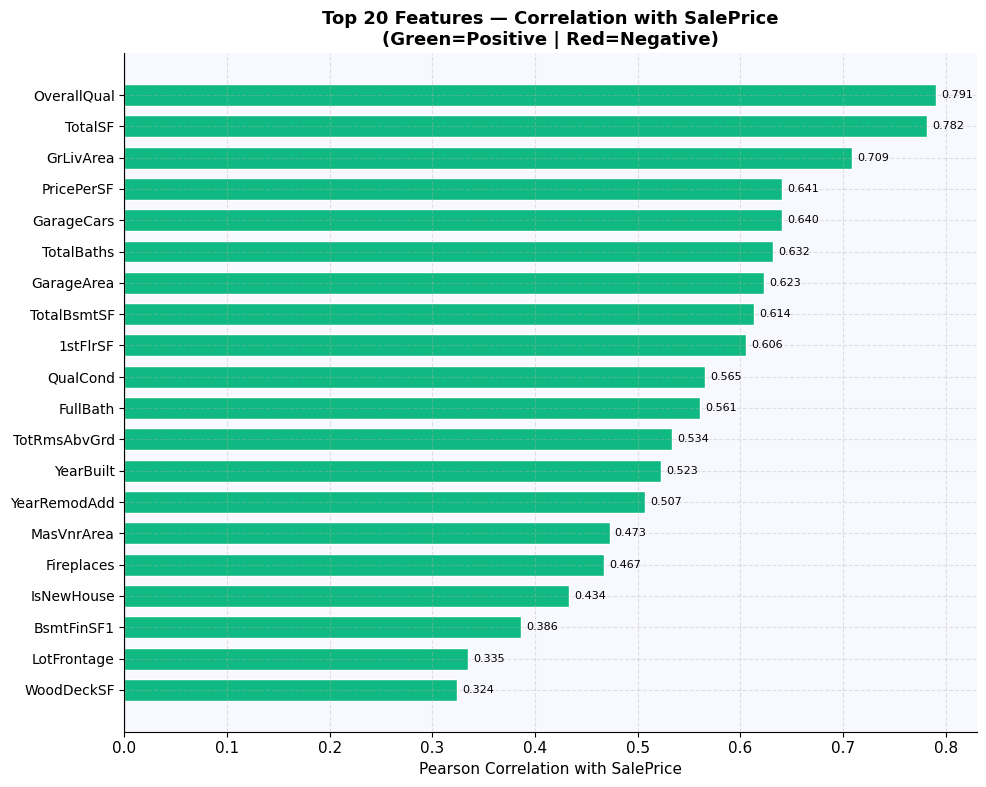

In [13]:
full_corr = (df_eng.corr(numeric_only=True)['SalePrice']
                   .abs()
                   .sort_values(ascending=False))

print("── TOP 20 Features by Absolute Correlation with SalePrice ──")
print(full_corr.iloc[1:21].to_string())

print("\n── BOTTOM 10 Features (Weakest Correlation) ──")
print(full_corr.iloc[-10:].to_string())

top20_list   = full_corr.iloc[1:21].index.tolist()
eng_in_top20 = [f for f in new_features if f in top20_list]
print(f"\nEngineered features in Top 20: {eng_in_top20}")

# Signed correlation for color
top20_signed = (df_eng.corr(numeric_only=True)['SalePrice']
                      .sort_values(ascending=False)
                      .iloc[1:21])

colors_bar = ['#10B981' if v > 0 else '#EF4444'
              for v in top20_signed.values]

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(range(len(top20_signed)), top20_signed.values,
               color=colors_bar, edgecolor='white', height=0.7)
ax.set_yticks(range(len(top20_signed)))
ax.set_yticklabels(top20_signed.index, fontsize=10)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson Correlation with SalePrice')
ax.set_title('Top 20 Features — Correlation with SalePrice\n'
             '(Green=Positive | Red=Negative)',
             fontsize=13, fontweight='bold')
ax.invert_yaxis()

for bar, val in zip(bars, top20_signed.values):
    ax.text(
        val + (0.005 if val > 0 else -0.005),
        bar.get_y() + bar.get_height()/2,
        f'{val:.3f}',
        va='center',
        ha='left' if val > 0 else 'right',
        fontsize=8
    )

plt.tight_layout()
plt.savefig('w3_chart8_feature_corr.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# Verified quality columns that exist in this dataset
all_possible_quality = [
    'ExterQual','ExterCond','BsmtQual','BsmtCond','HeatingQC',
    'KitchenQual','FireplaceQu','GarageQual','GarageCond','PoolQC',
    'BsmtExposure','BsmtFinType1','BsmtFinType2','GarageFinish',
    'Fence','Electrical'
]

cat_cols = df_eng.select_dtypes(include='object').columns.tolist()
quality_cols = [c for c in all_possible_quality if c in cat_cols]
print(f"Quality columns found: {quality_cols}")

encoding_decisions = {}

for col in cat_cols:
    n_unique    = df_eng[col].nunique()
    null_pct    = df_eng[col].isna().mean()
    top_val_pct = df_eng[col].value_counts(normalize=True).iloc[0]

    if null_pct > 0.5:
        strategy = 'drop'
        reason   = f'{null_pct:.0%} missing values'
    elif top_val_pct > 0.95:
        strategy = 'drop'
        reason   = f'Single value dominates {top_val_pct:.0%}'
    elif col in quality_cols:
        strategy = 'label_encode'
        reason   = 'Ordinal quality scale (Po to Ex)'
    elif n_unique <= 10:
        strategy = 'onehot_encode'
        reason   = f'Nominal, {n_unique} categories'
    else:
        strategy = 'frequency_encode'
        reason   = f'Nominal, {n_unique} categories — high cardinality'

    encoding_decisions[col] = {
        'n_unique': n_unique,
        'null_pct': f'{null_pct:.1%}',
        'strategy': strategy,
        'reason'  : reason
    }

    print(f"{'─'*60}")
    print(f"Column : {col:20s} | Unique: {n_unique:3d} | "
          f"Null: {null_pct:.1%} | Strategy: {strategy}")
    print(f"Reason : {reason}")
    print(df_eng[col].value_counts().head(4).to_string())

dec_df = pd.DataFrame(encoding_decisions).T
print("\n\n── ENCODING DECISION SUMMARY ──")
print(dec_df.to_string())
print(f"\nStrategy counts:\n{dec_df['strategy'].value_counts().to_string()}")

Quality columns found: ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC', 'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'GarageFinish', 'Fence', 'Electrical']
────────────────────────────────────────────────────────────
Column : MSZoning             | Unique:   5 | Null: 0.0% | Strategy: onehot_encode
Reason : Nominal, 5 categories
MSZoning
RL    1151
RM     218
FV      65
RH      16
────────────────────────────────────────────────────────────
Column : Street               | Unique:   2 | Null: 0.0% | Strategy: drop
Reason : Single value dominates 100%
Street
Pave    1454
Grvl       6
────────────────────────────────────────────────────────────
Column : Alley                | Unique:   2 | Null: 93.8% | Strategy: drop
Reason : 94% missing values
Alley
Grvl    50
Pave    41
────────────────────────────────────────────────────────────
Column : LotShape             | Unique:   4 | Null: 0.0% | Strategy: one

In [15]:
df_encoded = df_eng.copy()
print(f"Shape BEFORE encoding: {df_encoded.shape}")

# ── (a) Label Encoding — Quality Columns ────────────────────────
quality_map = {'Ex':5, 'Gd':4, 'TA':3, 'Fa':2, 'Po':1, 'NA':0, 'None':0}

label_cols = [c for c in quality_cols if c in df_encoded.columns]
for col in label_cols:
    df_encoded[col] = df_encoded[col].fillna('NA').map(quality_map)
    # Any unmapped value becomes NaN — fill with 0
    df_encoded[col] = df_encoded[col].fillna(0).astype(int)
    print(f"  Label-encoded: {col}")

# ── (b) One-Hot Encoding — Nominal, ≤10 categories ──────────────
ohe_cols = [col for col, info in encoding_decisions.items()
            if info['strategy'] == 'onehot_encode'
            and col in df_encoded.columns]

print(f"\nOHE columns ({len(ohe_cols)}): {ohe_cols}")
df_encoded = pd.get_dummies(df_encoded, columns=ohe_cols,
                             drop_first=True, dtype=int)

# ── (c) Frequency Encoding — High-cardinality Nominal ───────────
freq_cols = [col for col, info in encoding_decisions.items()
             if info['strategy'] == 'frequency_encode'
             and col in df_encoded.columns]

print(f"\nFrequency-encoded ({len(freq_cols)}): {freq_cols}")
for col in freq_cols:
    freq_map = df_encoded[col].value_counts(normalize=True)
    df_encoded[col] = df_encoded[col].map(freq_map)

# ── (d) Drop columns marked drop ─────────────────────────────────
drop_cols = [col for col, info in encoding_decisions.items()
             if info['strategy'] == 'drop'
             and col in df_encoded.columns]
df_encoded.drop(columns=drop_cols, errors='ignore', inplace=True)
print(f"\nDropped ({len(drop_cols)}): {drop_cols}")

# ── Verify ────────────────────────────────────────────────────────
remaining_obj = df_encoded.select_dtypes(include='object').columns.tolist()

# Drop QualGroup column created in Step 6 if still present
if 'QualGroup' in df_encoded.columns:
    df_encoded.drop(columns=['QualGroup'], inplace=True)
    print("Dropped helper column: QualGroup")

remaining_obj = df_encoded.select_dtypes(include='object').columns.tolist()
print(f"\nRemaining object columns (should be []): {remaining_obj}")
print(f"Shape AFTER encoding: {df_encoded.shape}")

Shape BEFORE encoding: (1460, 90)
  Label-encoded: ExterQual
  Label-encoded: ExterCond
  Label-encoded: BsmtQual
  Label-encoded: BsmtCond
  Label-encoded: HeatingQC
  Label-encoded: KitchenQual
  Label-encoded: FireplaceQu
  Label-encoded: GarageQual
  Label-encoded: GarageCond
  Label-encoded: PoolQC
  Label-encoded: BsmtExposure
  Label-encoded: BsmtFinType1
  Label-encoded: BsmtFinType2
  Label-encoded: GarageFinish
  Label-encoded: Fence
  Label-encoded: Electrical

OHE columns (16): ['MSZoning', 'LotShape', 'LandContour', 'LotConfig', 'LandSlope', 'Condition1', 'BldgType', 'HouseStyle', 'RoofStyle', 'Foundation', 'CentralAir', 'Functional', 'GarageType', 'PavedDrive', 'SaleType', 'SaleCondition']

Frequency-encoded (3): ['Neighborhood', 'Exterior1st', 'Exterior2nd']

Dropped (12): ['Street', 'Alley', 'Utilities', 'Condition2', 'RoofMatl', 'MasVnrType', 'Heating', 'GarageQual', 'GarageCond', 'PoolQC', 'Fence', 'MiscFeature']
Dropped helper column: QualGroup

Remaining object colu

X_train shape: (1168, 130)
X_test  shape: (292, 130)

── Before vs After Scaling ──
Feature        Scaler              Before Mean   After Mean  Before Std  After Std
────────────────────────────────────────────────────────────────────────
GrLivArea      StandardScaler          1527.40      -0.0000      524.43     1.0000
GrLivArea      MinMaxScaler            1527.40       0.2248      524.43     0.0988
GrLivArea      RobustScaler            1527.40       0.0842      524.43     0.8112

LotArea        StandardScaler         10689.64       0.0000    10759.37     1.0000
LotArea        MinMaxScaler           10689.64       0.0439    10759.37     0.0503
LotArea        RobustScaler           10689.64       0.2649    10759.37     2.6150

YearBuilt      StandardScaler          1970.97      -0.0000       30.68     1.0000
YearBuilt      MinMaxScaler            1970.97       0.7171       30.68     0.2222
YearBuilt      RobustScaler            1970.97      -0.0215       30.68     0.6388



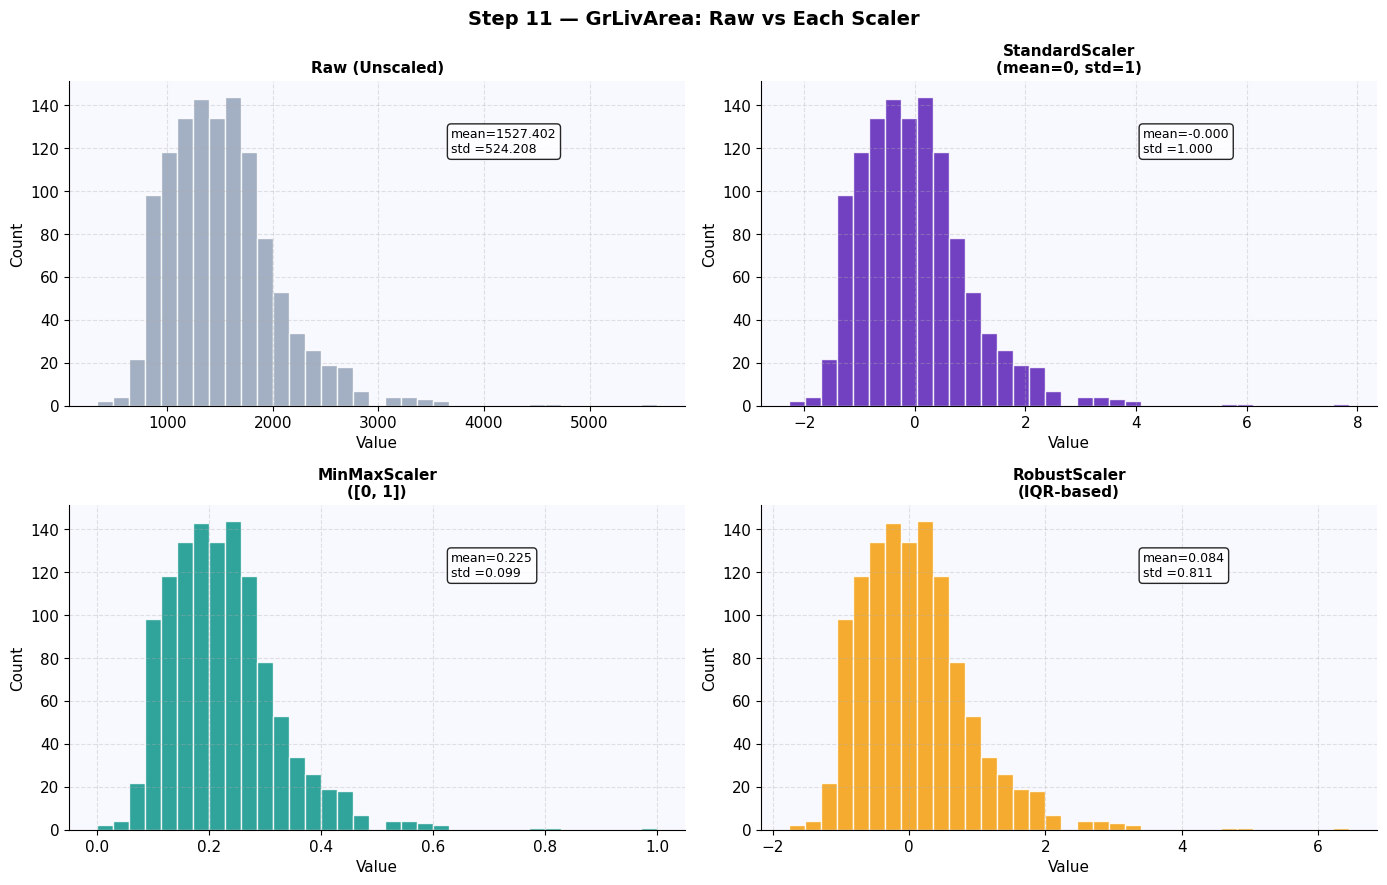

Chart 11 saved.


In [16]:
# Build X and y — numeric only, fill remaining NaNs
X = (df_encoded
     .select_dtypes(include='number')
     .drop(columns=['SalePrice','PricePerSF','Id'], errors='ignore')
     .copy())
X = X.fillna(X.median())

y = df_encoded['SalePrice'].fillna(df_encoded['SalePrice'].median())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test  shape: {X_test.shape}")

# Three scalers — ALWAYS fit on train only
scalers = {
    'StandardScaler': StandardScaler(),
    'MinMaxScaler'  : MinMaxScaler(),
    'RobustScaler'  : RobustScaler(),
}

scaled_results = {}
for name, scaler in scalers.items():
    X_tr_sc = scaler.fit_transform(X_train)
    X_te_sc = scaler.transform(X_test)
    scaled_results[name] = {
        'train' : X_tr_sc,
        'test'  : X_te_sc,
        'scaler': scaler
    }

# ── Comparison Table ──────────────────────────────────────────────
sample_feats = ['GrLivArea', 'LotArea', 'YearBuilt']
feat_indices = [list(X_train.columns).index(f)
                for f in sample_feats if f in X_train.columns]
sample_feats = [f for f in sample_feats if f in X_train.columns]

print("\n── Before vs After Scaling ──")
print(f"{'Feature':<14} {'Scaler':<18} {'Before Mean':>12}"
      f" {'After Mean':>12} {'Before Std':>11} {'After Std':>10}")
print('─' * 72)

for fi, feat in zip(feat_indices, sample_feats):
    raw_mean = X_train.iloc[:, fi].mean()
    raw_std  = X_train.iloc[:, fi].std()
    for sname, sdata in scaled_results.items():
        sc_mean = sdata['train'][:, fi].mean()
        sc_std  = sdata['train'][:, fi].std()
        print(f"{feat:<14} {sname:<18} {raw_mean:>12.2f}"
              f" {sc_mean:>12.4f} {raw_std:>11.2f} {sc_std:>10.4f}")
    print()

# ── Histogram comparison ──────────────────────────────────────────
if 'GrLivArea' in X_train.columns:
    gla_idx  = list(X_train.columns).index('GrLivArea')
    raw_vals = X_train['GrLivArea'].values

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    fig.suptitle('Step 11 — GrLivArea: Raw vs Each Scaler',
                 fontsize=14, fontweight='bold')

    data_list = [raw_vals] + [
        scaled_results[s]['train'][:, gla_idx] for s in scalers
    ]
    titles = ['Raw (Unscaled)',
              'StandardScaler\n(mean=0, std=1)',
              'MinMaxScaler\n([0, 1])',
              'RobustScaler\n(IQR-based)']
    colors = ['#94A3B8','#5B21B6','#0D9488','#F59E0B']

    for ax, data, title, color in zip(axes.flat, data_list, titles, colors):
        ax.hist(data, bins=35, color=color,
                edgecolor='white', alpha=0.85)
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.set_xlabel('Value')
        ax.set_ylabel('Count')
        ax.annotate(
            f'mean={data.mean():.3f}\nstd ={data.std():.3f}',
            xy=(0.62, 0.78), xycoords='axes fraction', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.85)
        )

    plt.tight_layout()
    plt.savefig('w3_chart11_scaling.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Chart 11 saved.")

## Step 11 — Scaler Selection for Week 4 Linear Regression

For Linear Regression I would choose StandardScaler because:
1. Linear regression is sensitive to feature scale — large-range features
   dominate coefficient magnitudes without scaling.
2. StandardScaler produces mean=0, std=1 which ensures Ridge/Lasso
   regularization penalties treat all features equally.
3. MinMaxScaler is more sensitive to outliers — one extreme house value
   compresses all others toward 0.
4. RobustScaler is ideal for preserving outliers (anomaly detection)
   which is not the goal here.

For tree-based models (Random Forest, XGBoost) — no scaling needed.
Trees split on thresholds and are invariant to monotonic transformations.

── Full Skewness Report ──
               Column  Skewness  Severity
       Functional_Sev 38.209946 Very High
       RoofStyle_Shed 26.990701 Very High
         SaleType_Con 26.990701 Very High
      Condition1_RRNe 26.990701 Very High
              MiscVal 24.476794 Very High
      Foundation_Wood 22.015094 Very High
         SaleType_Oth 22.015094 Very High
SaleCondition_AdjLand 19.045943 Very High
        LotConfig_FR3 19.045943 Very High
         SaleType_CWD 19.045943 Very High
      Condition1_RRNn 17.017590 Very High
       SaleType_ConLw 17.017590 Very High
      Functional_Maj2 17.017590 Very High
       SaleType_ConLI 17.017590 Very High
     Foundation_Stone 15.518770 Very High
             PoolArea 14.828374 Very High
    RoofStyle_Mansard 14.352680 Very High
    HouseStyle_2.5Fin 13.411750 Very High
      Condition1_PosA 13.411750 Very High
   GarageType_CarPort 12.631556 Very High
       SaleType_ConLD 12.631556 Very High
              LotArea 12.207688 Very High
       

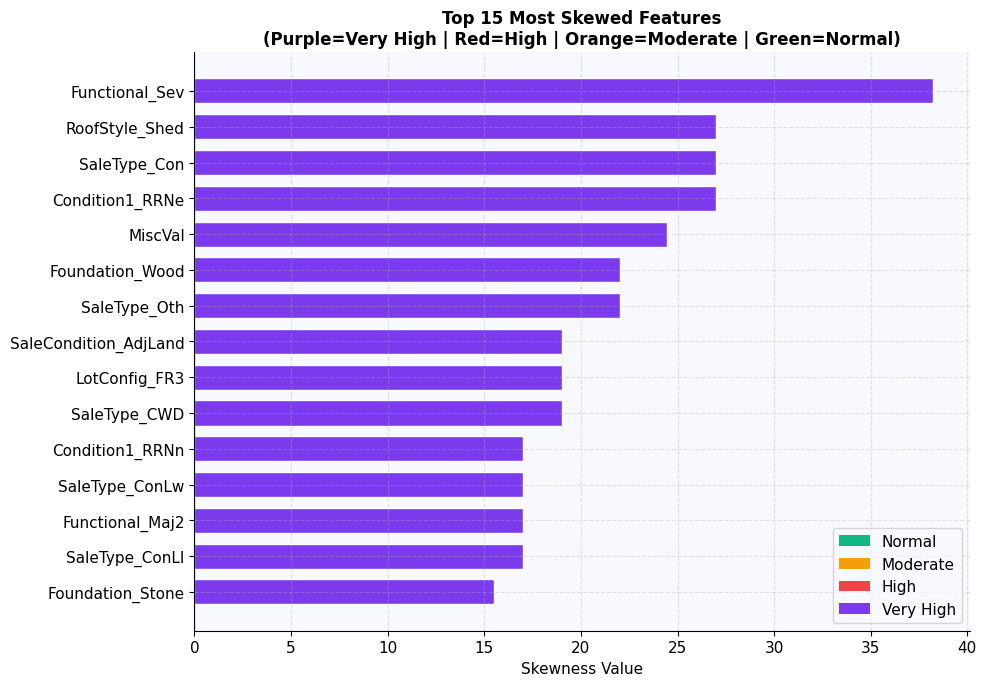

In [17]:
num_cols_only = df_encoded.select_dtypes(include='number').columns.tolist()
exclude       = ['SalePrice','PricePerSF','Id']
num_cols_skew = [c for c in num_cols_only if c not in exclude]

skew_series = (df_encoded[num_cols_skew]
               .skew()
               .sort_values(ascending=False, key=abs))

def skew_severity(s):
    s = abs(s)
    if s < 0.5:  return 'Normal'
    if s < 1.0:  return 'Moderate'
    if s < 2.0:  return 'High'
    return 'Very High'

skew_df = pd.DataFrame({
    'Column'  : skew_series.index,
    'Skewness': skew_series.values,
    'Severity': [skew_severity(v) for v in skew_series.values]
})

print("── Full Skewness Report ──")
print(skew_df.to_string(index=False))

high_count = skew_df['Severity'].isin(['High','Very High']).sum()
pct        = high_count / len(skew_df) * 100
print(f"\n|skew| > 1 features      : {high_count}")
print(f"Percentage highly skewed : {pct:.1f}%")

# ── Horizontal bar chart: top 15 most skewed ──────────────────────
top15_skew = skew_df.head(15).copy()
sev_color  = {
    'Normal'   : '#10B981',
    'Moderate' : '#F59E0B',
    'High'     : '#EF4444',
    'Very High': '#7C3AED'
}
bar_colors = [sev_color[s] for s in top15_skew['Severity']]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(range(len(top15_skew)), top15_skew['Skewness'],
        color=bar_colors, edgecolor='white', height=0.7)
ax.set_yticks(range(len(top15_skew)))
ax.set_yticklabels(top15_skew['Column'])
ax.invert_yaxis()
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Skewness Value')
ax.set_title('Top 15 Most Skewed Features\n'
             '(Purple=Very High | Red=High | Orange=Moderate | Green=Normal)',
             fontsize=12, fontweight='bold')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=s)
                   for s, c in sev_color.items()]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.savefig('w3_chart12_skewness.png', dpi=150, bbox_inches='tight')
plt.show()

Applying log1p to 97 features with |skew| > 0.75

Box-Cox lambda for SalePrice : -0.0769
(lambda≈0=log | lambda≈0.5=sqrt | lambda≈1=no transform)

── SalePrice Transformation Comparison ──
Original  skew : 1.883
Log1p     skew : 0.121
Sqrt      skew : 0.943
Box-Cox   skew : -0.009

Best transformation: log1p (skewness closest to 0)


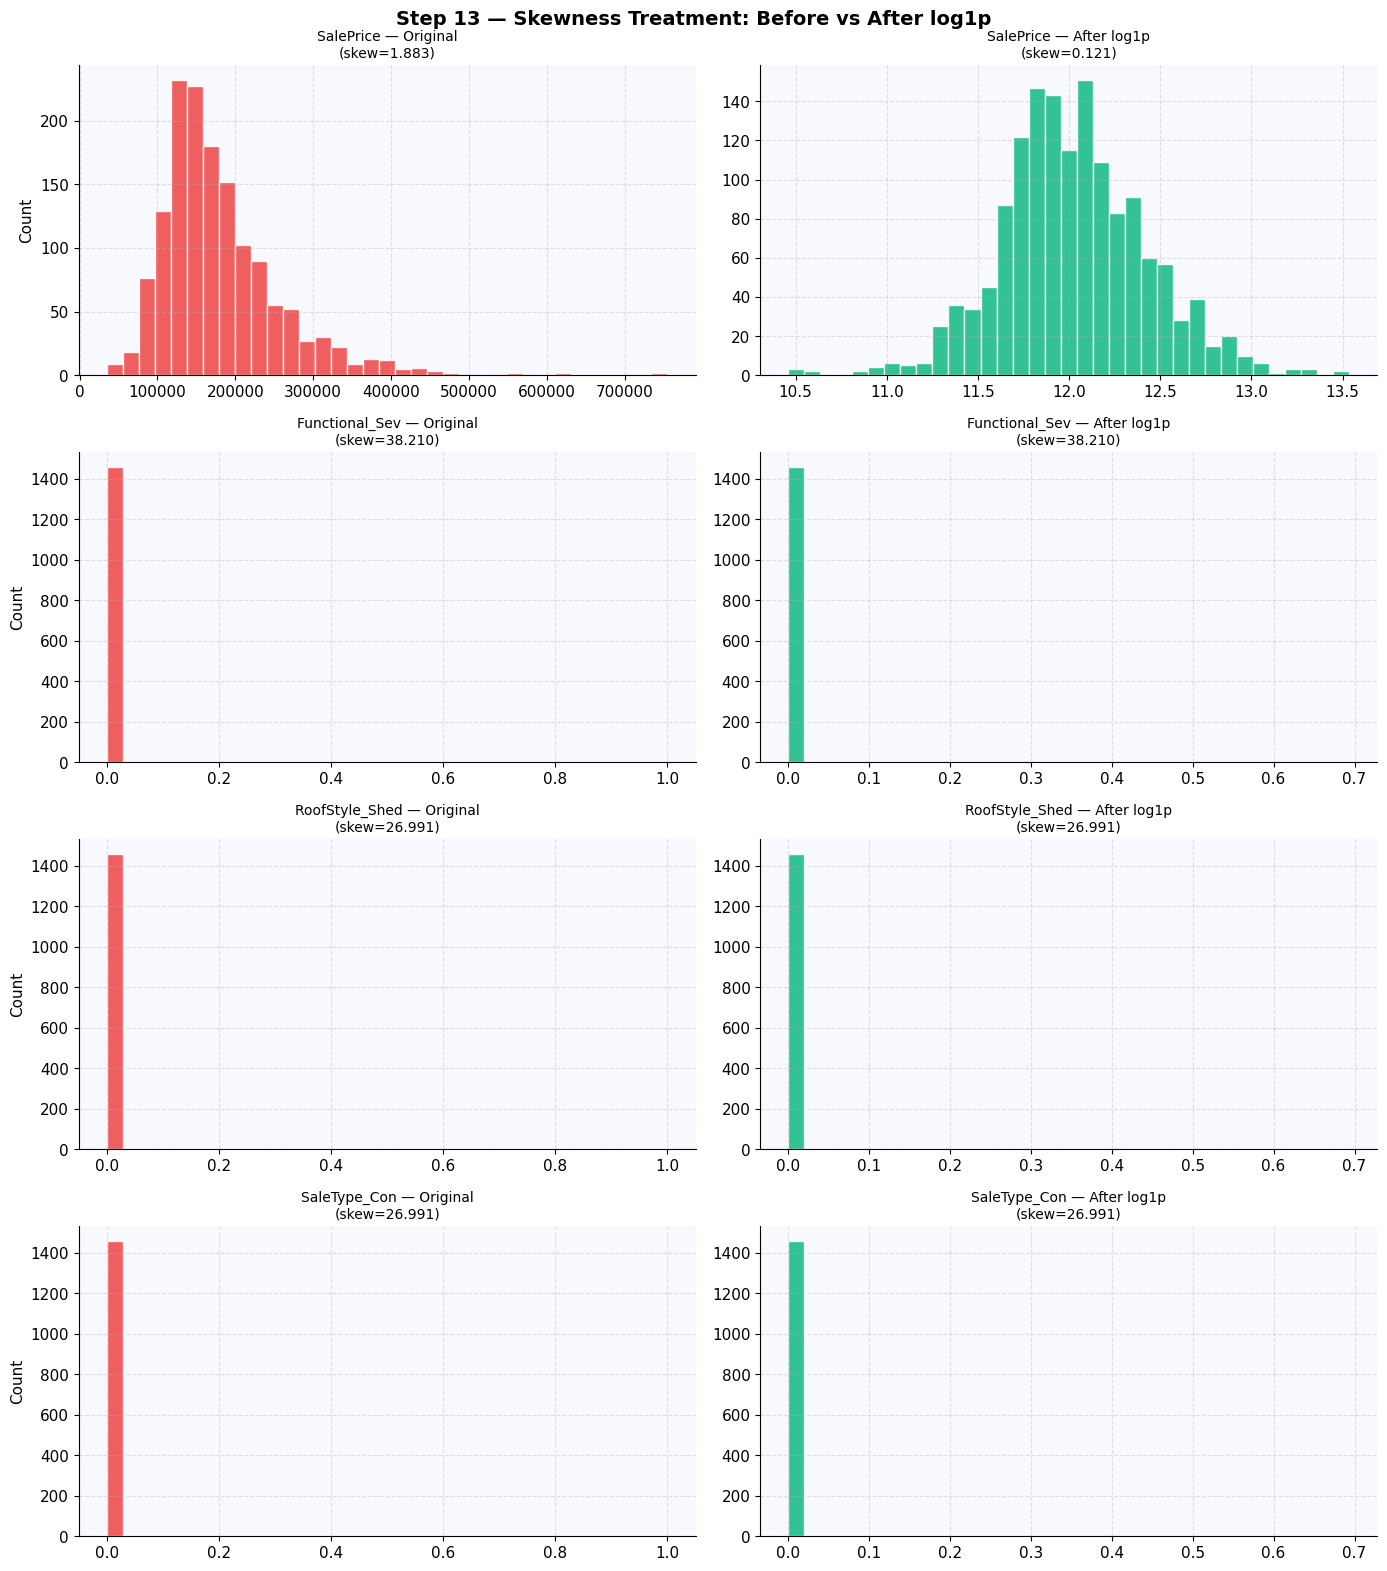

Chart 13 saved.


In [18]:
df_transformed = df_encoded.copy()

# Columns to transform — |skew| > 0.75, not target, not Id
high_skew_cols = skew_df.loc[
    skew_df['Skewness'].abs() > 0.75, 'Column'
].tolist()
high_skew_cols = [c for c in high_skew_cols
                  if c in df_transformed.columns]

print(f"Applying log1p to {len(high_skew_cols)} features with |skew| > 0.75")

for col in high_skew_cols:
    if df_transformed[col].min() >= 0:
        df_transformed[col] = np.log1p(df_transformed[col])
    else:
        print(f"  Skipped {col} — has negative values")

# ── SalePrice: compare all 3 transformations ─────────────────────
sp      = df_encoded['SalePrice'].dropna()
sp_log  = np.log1p(sp)
sp_sqrt = np.sqrt(sp)
sp_bc, lambda_bc = boxcox(sp[sp > 0])

print(f"\nBox-Cox lambda for SalePrice : {lambda_bc:.4f}")
print("(lambda≈0=log | lambda≈0.5=sqrt | lambda≈1=no transform)")

df_transformed['SalePrice_transformed'] = np.log1p(
    df_transformed['SalePrice']
)

print(f"\n── SalePrice Transformation Comparison ──")
print(f"Original  skew : {sp.skew():.3f}")
print(f"Log1p     skew : {sp_log.skew():.3f}")
print(f"Sqrt      skew : {sp_sqrt.skew():.3f}")
print(f"Box-Cox   skew : {pd.Series(sp_bc).skew():.3f}")
print("\nBest transformation: log1p (skewness closest to 0)")

# ── 4x2 Before/After figure ───────────────────────────────────────
viz_feats  = [c for c in high_skew_cols[:3]
              if c in df_encoded.columns]
all_feat4  = ['SalePrice'] + viz_feats

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
fig.suptitle('Step 13 — Skewness Treatment: Before vs After log1p',
             fontsize=14, fontweight='bold')

for row, feat in enumerate(all_feat4):
    orig  = df_encoded[feat].dropna()
    trans = np.log1p(orig)

    axes[row, 0].hist(orig, bins=35, color='#EF4444',
                      edgecolor='white', alpha=0.85)
    axes[row, 0].set_title(f'{feat} — Original\n'
                            f'(skew={orig.skew():.3f})', fontsize=10)
    axes[row, 0].set_ylabel('Count')

    axes[row, 1].hist(trans, bins=35, color='#10B981',
                      edgecolor='white', alpha=0.85)
    axes[row, 1].set_title(f'{feat} — After log1p\n'
                            f'(skew={trans.skew():.3f})', fontsize=10)

plt.tight_layout()
plt.savefig('w3_chart13_skew_treatment.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 13 saved.")

In [21]:
df_final = df_transformed.copy()
df_final = df_final.fillna(df_final.median(numeric_only=True))

X_all = (df_final
         .select_dtypes(include='number')
         .drop(columns=['SalePrice','SalePrice_transformed',
                        'PricePerSF','Id'], errors='ignore'))

y_all = df_final['SalePrice_transformed'].fillna(
        df_final['SalePrice_transformed'].median())

print(f"Features before selection: {X_all.shape[1]}")

# ── (a) Correlation-based: top 30 ────────────────────────────────
corr_target = X_all.corrwith(y_all).abs().sort_values(ascending=False)
top30       = corr_target.head(30).index.tolist()
X_top30     = X_all[top30]
print(f"After correlation filter (top 30): {X_top30.shape[1]}")

# ── (b) Variance threshold ────────────────────────────────────────
vt       = VarianceThreshold(threshold=0.01)
X_var    = vt.fit_transform(X_top30)
var_mask = vt.get_support()
var_cols = [c for c, m in zip(top30, var_mask) if m]
print(f"After variance threshold (>0.01)  : {len(var_cols)}")

# ── (c) Remove multicollinear pairs (r > 0.95) ───────────────────
X_var_df    = X_top30[var_cols]
corr_matrix = X_var_df.corr().abs()
upper       = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop_mc = []
for col in upper.columns:
    high_corr_partners = upper[col][upper[col] > 0.95].index.tolist()
    for partner in high_corr_partners:
        drop_c = (col if corr_target.get(col, 0) < corr_target.get(partner, 0) else partner)
        if drop_c not in to_drop_mc:
            to_drop_mc.append(drop_c)
print(f"Multicollinear features dropped   : {to_drop_mc}")
final_features = [c for c in var_cols if c not in to_drop_mc]

# ── Final summary ─────────────────────────────────────────────────
final_df = pd.DataFrame({
    'Feature'    : final_features,
    'Correlation': [corr_target.get(f, 0) for f in final_features],
    'Dtype'      : [X_all[f].dtype for f in final_features]
}).sort_values('Correlation', ascending=False)

print(f"\n── Final Feature Set ──")
print(final_df.to_string(index=False))

pct_eliminated = (1 - len(final_features) / X_all.shape[1]) * 100
print(f"\nOriginal : {X_all.shape[1]}  features")
print(f"Final    : {len(final_features)} features")
print(f"Eliminated: {pct_eliminated:.1f}%")

Features before selection: 130
After correlation filter (top 30): 30
After variance threshold (>0.01)  : 30
Multicollinear features dropped   : ['YearBuilt', 'YearRemodAdd']

── Final Feature Set ──
          Feature  Correlation   Dtype
      OverallQual     0.817185   int64
          TotalSF     0.807140 float64
        GrLivArea     0.730254 float64
       GarageCars     0.680625   int64
        ExterQual     0.678191 float64
       TotalBaths     0.673011 float64
      KitchenQual     0.667893   int64
       GarageArea     0.650888   int64
         1stFlrSF     0.608955 float64
         QualCond     0.606873   int64
         FullBath     0.594771   int64
         HouseAge     0.587290   int64
       RemodelAge     0.568136   int64
      FireplaceQu     0.546362   int64
     TotRmsAbvGrd     0.534422   int64
 Foundation_PConc     0.530840   int64
         BsmtQual     0.498605 float64
       Fireplaces     0.489450   int64
        HeatingQC     0.473762   int64
      OpenPorchSF    

── Function 1: visualize_distributions ──


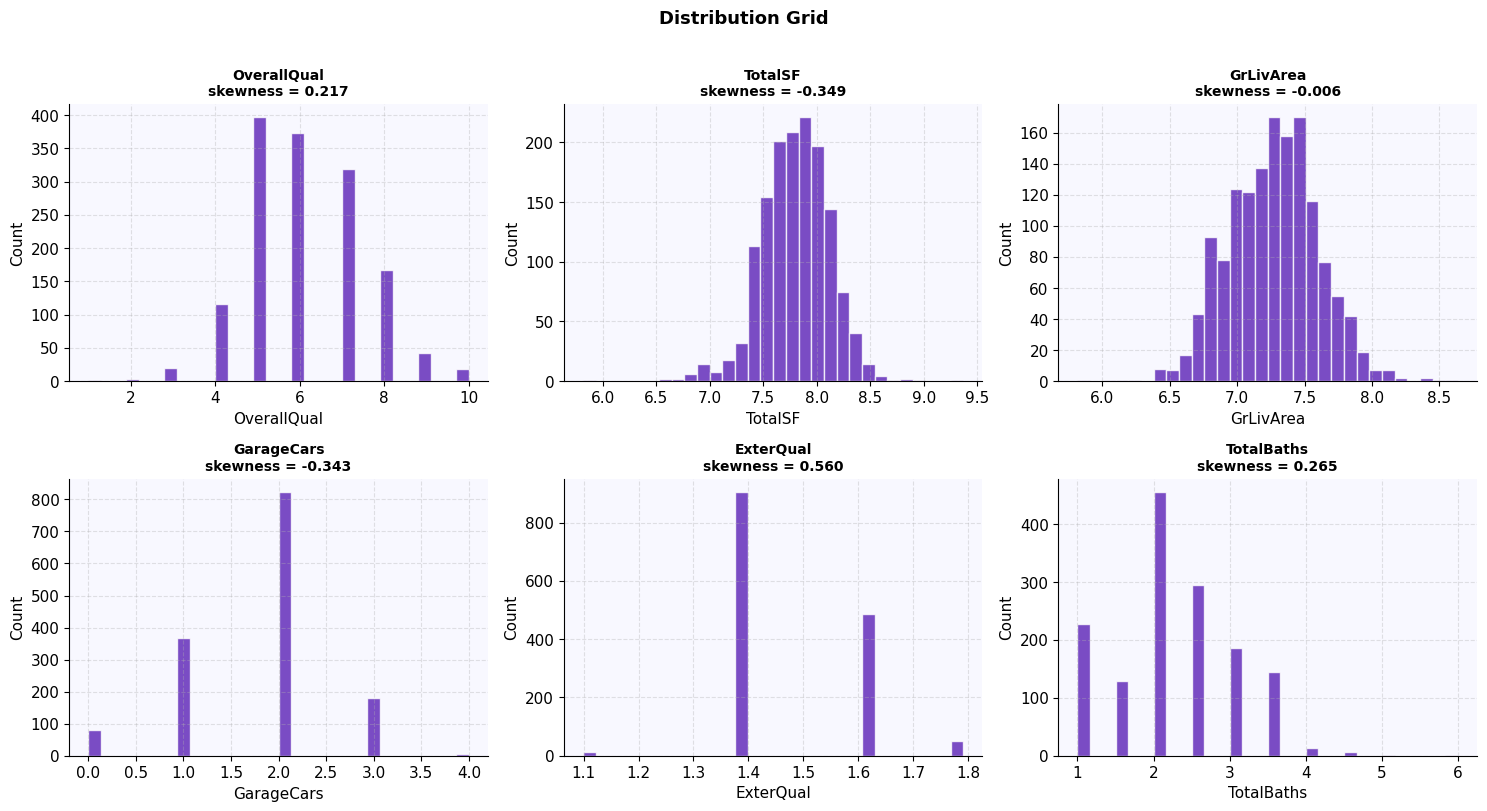


── Function 2: encode_quality_column ──
Mapping: {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'NA': 0, 'None': 0}
KitchenQual
3    735
4    586
5    100
2     39

── Function 3: full_scaling_pipeline ──

standard   → mean=-0.0000, std=1.0000, scaler=StandardScaler

minmax     → mean=0.4524, std=0.3310, scaler=MinMaxScaler

robust     → mean=-0.0047, std=0.8954, scaler=RobustScaler


In [22]:
def visualize_distributions(df: pd.DataFrame,
                             cols: list,
                             n_cols: int = 3) -> None:
    """
    Create a multi-panel histogram grid for a list of columns.

    Parameters
    ----------
    df     : pd.DataFrame  Input dataframe
    cols   : list[str]     Column names to visualize
    n_cols : int           Columns per row in the grid (default 3)
    """
    n_rows = -(-len(cols) // n_cols)
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(5 * n_cols, 4 * n_rows))
    axes = np.array(axes).flatten()

    for i, col in enumerate(cols):
        ax   = axes[i]
        data = df[col].dropna()
        skew = data.skew()
        ax.hist(data, bins=30, color='#5B21B6',
                edgecolor='white', alpha=0.8)
        ax.set_title(f'{col}\nskewness = {skew:.3f}',
                     fontsize=10, fontweight='bold')
        ax.set_xlabel(col)
        ax.set_ylabel('Count')

    for j in range(len(cols), len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Distribution Grid', fontsize=13,
                 fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()


def encode_quality_column(series: pd.Series,
                           quality_map: dict = None) -> tuple:
    """
    Encode an ordinal quality categorical column to integers.

    Parameters
    ----------
    series      : pd.Series  Categorical series to encode
    quality_map : dict|None  Custom map; if None uses standard Ex-Po scale

    Returns
    -------
    encoded_series : pd.Series  Integer-encoded series
    mapping_used   : dict       The mapping that was applied
    """
    default_map  = {'Ex':5,'Gd':4,'TA':3,'Fa':2,'Po':1,'NA':0,'None':0}
    mapping_used = quality_map if quality_map is not None else default_map
    encoded      = series.fillna('NA').map(mapping_used).fillna(0).astype(int)
    return encoded, mapping_used


def full_scaling_pipeline(X_train: np.ndarray,
                           X_test: np.ndarray,
                           method: str = 'standard') -> tuple:
    """
    Fit a scaler on X_train and transform both splits.

    Parameters
    ----------
    X_train : array-like  Training features
    X_test  : array-like  Test features
    method  : str         'standard' | 'minmax' | 'robust'

    Returns
    -------
    X_train_scaled : np.ndarray
    X_test_scaled  : np.ndarray
    fitted_scaler  : fitted scaler object
    """
    scaler_map = {
        'standard': StandardScaler(),
        'minmax'  : MinMaxScaler(),
        'robust'  : RobustScaler(),
    }
    if method not in scaler_map:
        raise ValueError(f"method must be one of {list(scaler_map.keys())}")

    scaler         = scaler_map[method]
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled, scaler


# ── Call all three functions ──────────────────────────────────────
print("── Function 1: visualize_distributions ──")
sample_cols = final_features[:6]
visualize_distributions(df_final, sample_cols, n_cols=3)

print("\n── Function 2: encode_quality_column ──")
enc_series, mapping_used = encode_quality_column(df['KitchenQual'])
print(f"Mapping: {mapping_used}")
print(enc_series.value_counts().to_string())

print("\n── Function 3: full_scaling_pipeline ──")
X_tr_np = X_all[final_features].fillna(0).values
X_te_np = X_all[final_features].fillna(0).values

for method in ['standard', 'minmax', 'robust']:
    tr_sc, te_sc, scaler_obj = full_scaling_pipeline(
        X_tr_np, X_te_np, method
    )
    print(f"\n{method:10s} → mean={tr_sc.mean():.4f}, "
          f"std={tr_sc.std():.4f}, "
          f"scaler={type(scaler_obj).__name__}")

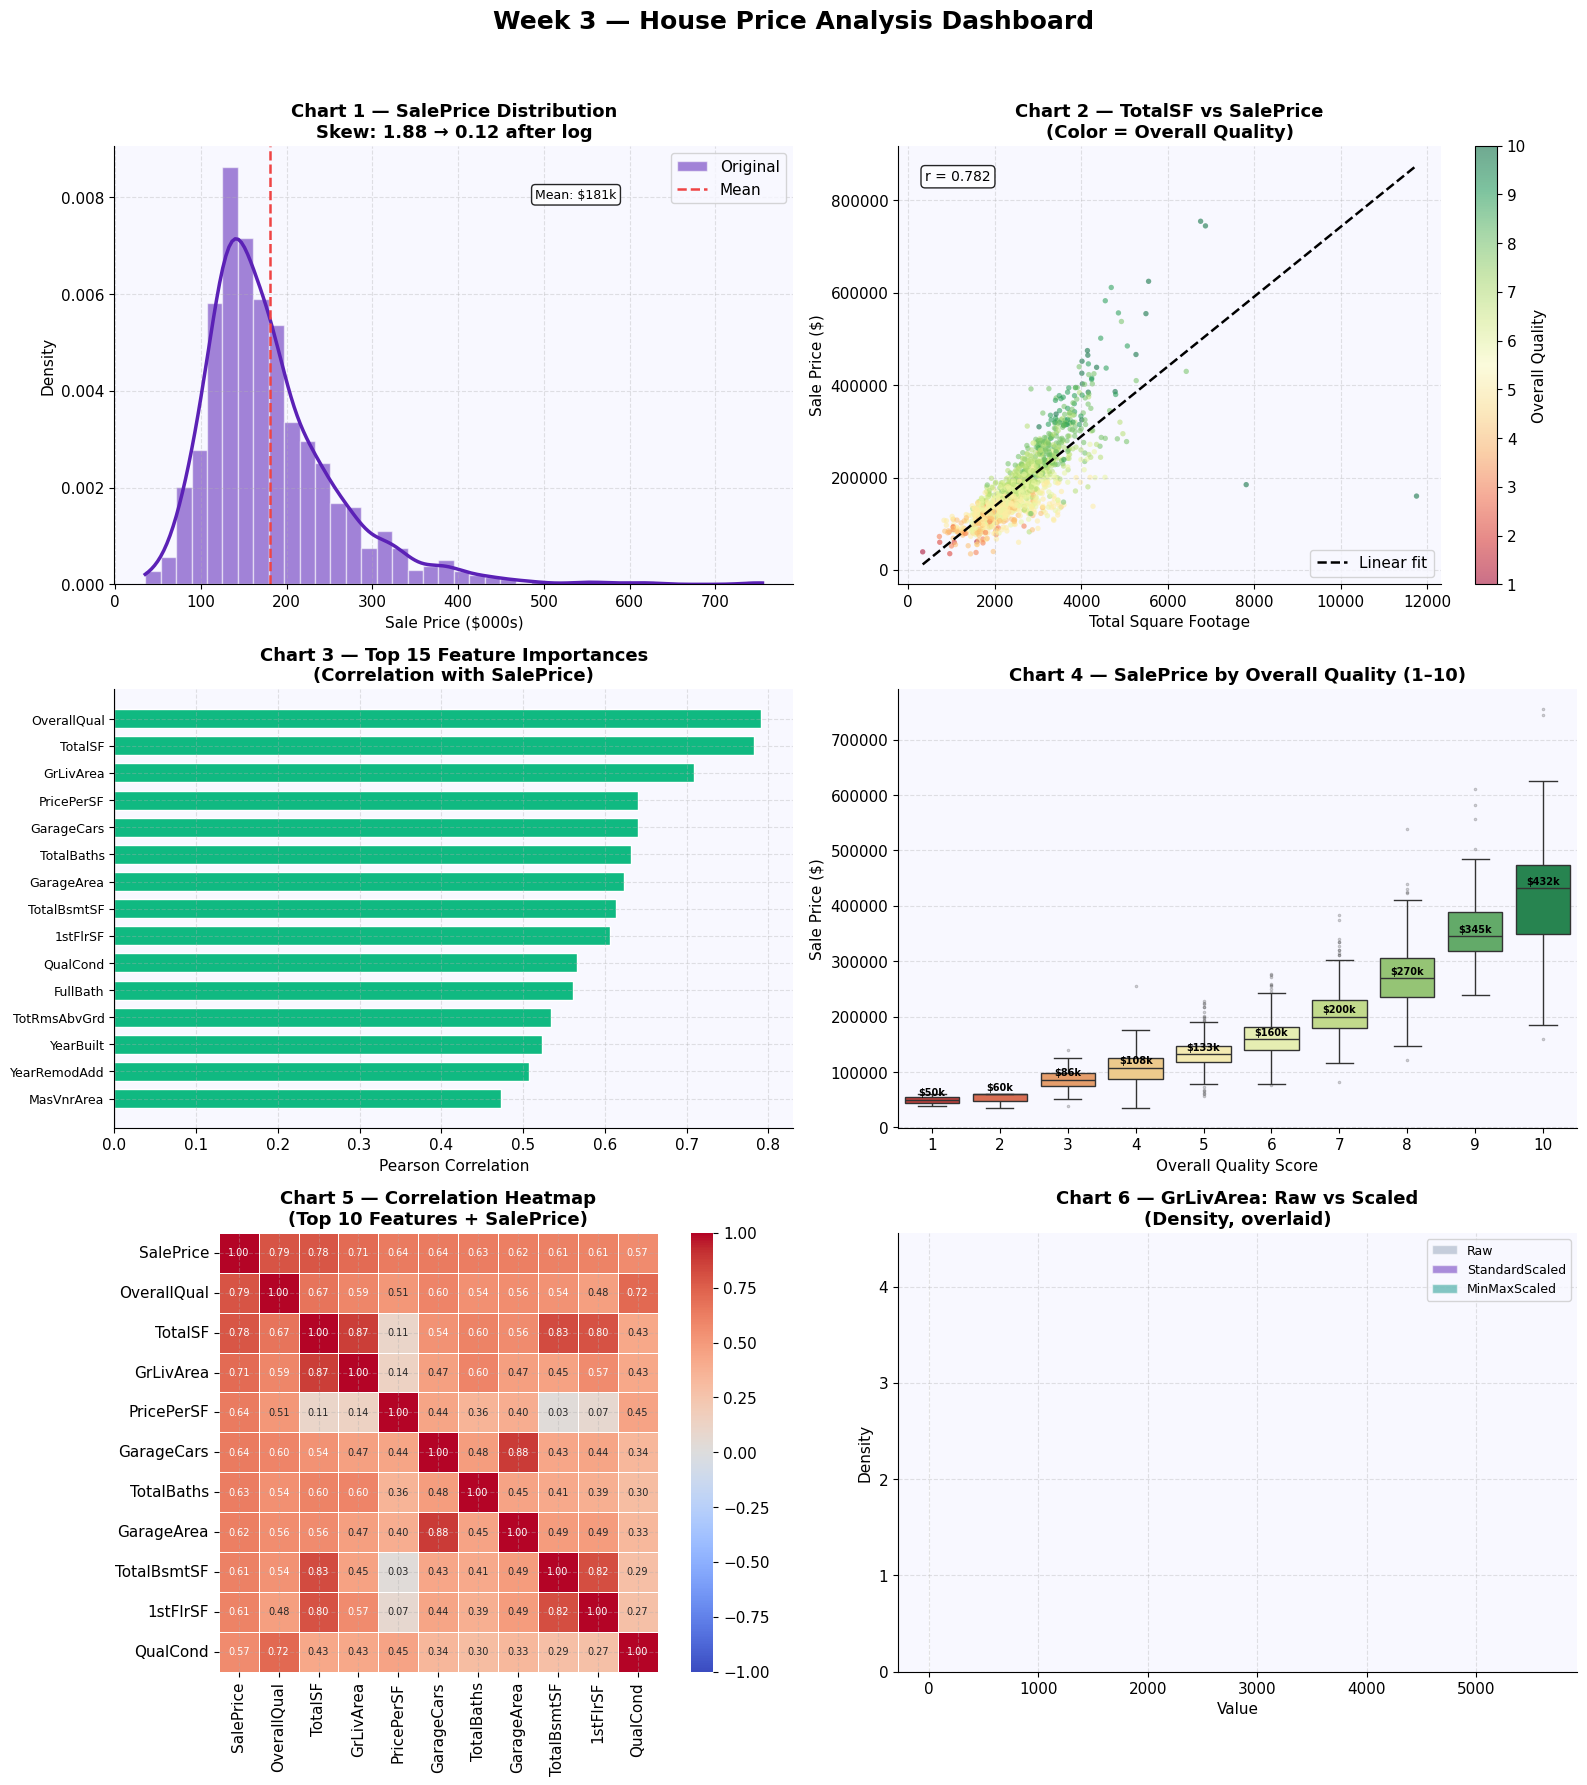

week3_dashboard.png saved at dpi=150.


In [23]:
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.patch.set_facecolor('#FFFFFF')
fig.suptitle('Week 3 — House Price Analysis Dashboard',
             fontsize=18, fontweight='bold', y=0.99)

# ── Chart 1: SalePrice distribution with KDE overlay ─────────────
ax = axes[0, 0]
sp_orig  = df['SalePrice'].dropna()
sp_log_d = np.log1p(sp_orig)

ax.hist(sp_orig / 1000, bins=40, color='#5B21B6',
        alpha=0.55, edgecolor='white', density=True, label='Original')
kde_orig = gaussian_kde(sp_orig / 1000)
x_range  = np.linspace((sp_orig/1000).min(), (sp_orig/1000).max(), 200)
ax.plot(x_range, kde_orig(x_range), color='#5B21B6', linewidth=2.5)
ax.axvline(sp_orig.mean()/1000, color='#EF4444',
           linestyle='--', linewidth=1.8, label='Mean')
ax.set_title(f'Chart 1 — SalePrice Distribution\n'
             f'Skew: {sp_orig.skew():.2f} → {sp_log_d.skew():.2f} after log',
             fontweight='bold')
ax.set_xlabel('Sale Price ($000s)')
ax.set_ylabel('Density')
ax.legend()
ax.annotate(f'Mean: ${sp_orig.mean()/1000:.0f}k',
            xy=(0.62, 0.88), xycoords='axes fraction', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))

# ── Chart 2: TotalSF vs SalePrice ────────────────────────────────
ax = axes[0, 1]
mask2 = df_eng[['TotalSF','SalePrice','OverallQual']].notna().all(axis=1)
sc2 = ax.scatter(
    df_eng.loc[mask2, 'TotalSF'],
    df_eng.loc[mask2, 'SalePrice'],
    c=df_eng.loc[mask2, 'OverallQual'],
    cmap='RdYlGn', alpha=0.55, s=15, edgecolors='none'
)
plt.colorbar(sc2, ax=ax, label='Overall Quality')
x2 = df_eng.loc[mask2, 'TotalSF'].values
y2 = df_eng.loc[mask2, 'SalePrice'].values
m, b = np.polyfit(x2, y2, 1)
ax.plot(np.sort(x2), m*np.sort(x2)+b, 'k--',
        linewidth=1.8, label='Linear fit')
r2, _ = stats.pearsonr(x2, y2)
ax.annotate(f'r = {r2:.3f}',
            xy=(0.05, 0.92), xycoords='axes fraction', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))
ax.set_title('Chart 2 — TotalSF vs SalePrice\n(Color = Overall Quality)',
             fontweight='bold')
ax.set_xlabel('Total Square Footage')
ax.set_ylabel('Sale Price ($)')
ax.legend()

# ── Chart 3: Top 15 features by absolute correlation ─────────────
ax = axes[1, 0]
feat_corr_signed = (df_eng.corr(numeric_only=True)['SalePrice']
                          .sort_values(ascending=False)
                          .iloc[1:16])
colors3 = ['#10B981' if v > 0 else '#EF4444'
           for v in feat_corr_signed.values]
ax.barh(range(len(feat_corr_signed)), feat_corr_signed.values,
        color=colors3, edgecolor='white', height=0.7)
ax.set_yticks(range(len(feat_corr_signed)))
ax.set_yticklabels(feat_corr_signed.index, fontsize=9)
ax.invert_yaxis()
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Chart 3 — Top 15 Feature Importances\n'
             '(Correlation with SalePrice)',
             fontweight='bold')
ax.set_xlabel('Pearson Correlation')

# ── Chart 4: SalePrice by OverallQual ────────────────────────────
ax = axes[1, 1]
qual_order4 = sorted(df['OverallQual'].dropna().unique().astype(int))
sns.boxplot(data=df, x='OverallQual', y='SalePrice',
            order=qual_order4, palette='RdYlGn', ax=ax,
            flierprops=dict(marker='.', markersize=3, alpha=0.3))
for i, qual in enumerate(qual_order4):
    med = df.loc[df['OverallQual']==qual, 'SalePrice'].median()
    ax.text(i, med + 3000, f'${med/1000:.0f}k',
            ha='center', va='bottom', fontsize=7, fontweight='bold')
ax.set_title('Chart 4 — SalePrice by Overall Quality (1–10)',
             fontweight='bold')
ax.set_xlabel('Overall Quality Score')
ax.set_ylabel('Sale Price ($)')

# ── Chart 5: Heatmap — top 10 features + SalePrice ───────────────
ax = axes[2, 0]
top11 = (df_eng.corr(numeric_only=True)['SalePrice']
               .abs()
               .sort_values(ascending=False)
               .head(11)
               .index.tolist())
sns.heatmap(df_eng[top11].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', vmin=-1, vmax=1, square=True,
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 7}, ax=ax)
ax.set_title('Chart 5 — Correlation Heatmap\n(Top 10 Features + SalePrice)',
             fontweight='bold')

# ── Chart 6: Scaling comparison overlay ──────────────────────────
ax = axes[2, 1]
if 'GrLivArea' in X_train.columns:
    gla_idx = list(X_train.columns).index('GrLivArea')
    raw_gla = X_train['GrLivArea'].values
    std_gla = scaled_results['StandardScaler']['train'][:, gla_idx]
    mm_gla  = scaled_results['MinMaxScaler']['train'][:, gla_idx]

    ax.hist(raw_gla, bins=30, alpha=0.5, color='#94A3B8',
            edgecolor='white', density=True, label='Raw')
    ax.hist(std_gla, bins=30, alpha=0.5, color='#5B21B6',
            edgecolor='white', density=True, label='StandardScaled')
    ax.hist(mm_gla,  bins=30, alpha=0.5, color='#0D9488',
            edgecolor='white', density=True, label='MinMaxScaled')
    ax.set_title('Chart 6 — GrLivArea: Raw vs Scaled\n(Density, overlaid)',
                 fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('week3_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("week3_dashboard.png saved at dpi=150.")

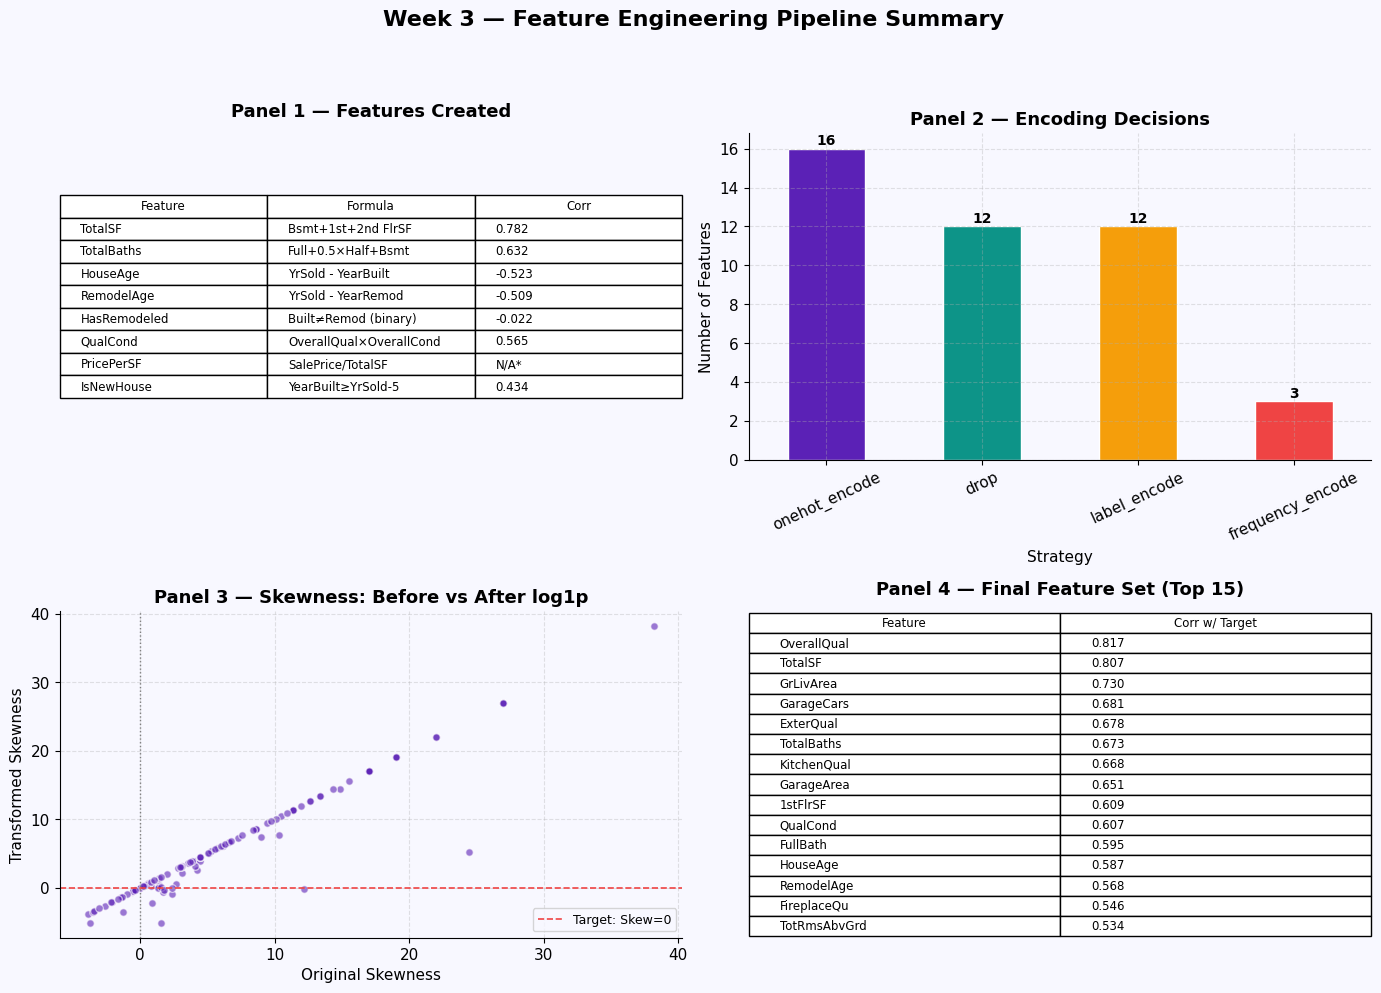

week3_fe_pipeline.png saved.


In [24]:
fig = plt.figure(figsize=(14, 10))
fig.patch.set_facecolor('#F8F8FF')
fig.suptitle('Week 3 — Feature Engineering Pipeline Summary',
             fontsize=16, fontweight='bold', y=0.99)

# ── Panel 1: Features Created table ─────────────────────────────
ax1 = fig.add_subplot(2, 2, 1)
ax1.axis('off')

feat_corrs = []
for f in new_features:
    if f == 'PricePerSF':
        feat_corrs.append('N/A*')
    else:
        c = df_eng[f].corr(df_eng['SalePrice'])
        feat_corrs.append(f'{c:.3f}')

feat_table_data = [
    ['TotalSF',       'Bsmt+1st+2nd FlrSF',   feat_corrs[0]],
    ['TotalBaths',    'Full+0.5×Half+Bsmt',    feat_corrs[1]],
    ['HouseAge',      'YrSold - YearBuilt',     feat_corrs[2]],
    ['RemodelAge',    'YrSold - YearRemod',     feat_corrs[3]],
    ['HasRemodeled',  'Built≠Remod (binary)',   feat_corrs[4]],
    ['QualCond',      'OverallQual×OverallCond',feat_corrs[5]],
    ['PricePerSF',    'SalePrice/TotalSF',      feat_corrs[6]],
    ['IsNewHouse',    'YearBuilt≥YrSold-5',     feat_corrs[7]],
]

tbl = ax1.table(
    cellText=feat_table_data,
    colLabels=['Feature', 'Formula', 'Corr'],
    loc='center', cellLoc='left'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8.5)
tbl.scale(1, 1.45)
ax1.set_title('Panel 1 — Features Created',
              fontweight='bold', pad=12)

# ── Panel 2: Encoding Decisions bar chart ────────────────────────
ax2 = fig.add_subplot(2, 2, 2)
enc_counts = pd.Series(
    [info['strategy'] for info in encoding_decisions.values()]
).value_counts()
colors2 = ['#5B21B6','#0D9488','#F59E0B','#EF4444']
enc_counts.plot(kind='bar', ax=ax2,
                color=colors2[:len(enc_counts)],
                edgecolor='white', rot=25)
for bar, val in zip(ax2.patches, enc_counts.values):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.2,
             str(val), ha='center',
             fontsize=10, fontweight='bold')
ax2.set_title('Panel 2 — Encoding Decisions', fontweight='bold')
ax2.set_xlabel('Strategy')
ax2.set_ylabel('Number of Features')

# ── Panel 3: Skewness before/after scatter ────────────────────────
ax3 = fig.add_subplot(2, 2, 3)
orig_skew_vals  = df_encoded[num_cols_skew].skew()
trans_skew_vals = df_transformed[
    [c for c in num_cols_skew if c in df_transformed.columns]
].skew()
common = orig_skew_vals.index.intersection(trans_skew_vals.index)

ax3.scatter(orig_skew_vals[common], trans_skew_vals[common],
            alpha=0.6, color='#5B21B6', s=30, edgecolors='white')
ax3.axhline(0, color='#EF4444', linestyle='--',
            linewidth=1.2, label='Target: Skew=0')
ax3.axvline(0, color='grey', linestyle=':', linewidth=1)
ax3.set_xlabel('Original Skewness')
ax3.set_ylabel('Transformed Skewness')
ax3.set_title('Panel 3 — Skewness: Before vs After log1p',
              fontweight='bold')
ax3.legend(fontsize=9)

# ── Panel 4: Top 15 selected features table ───────────────────────
ax4 = fig.add_subplot(2, 2, 4)
ax4.axis('off')
top15_sel  = final_df.head(15)
tbl2_data  = [[row['Feature'], f"{row['Correlation']:.3f}"]
              for _, row in top15_sel.iterrows()]
tbl2 = ax4.table(
    cellText=tbl2_data,
    colLabels=['Feature', 'Corr w/ Target'],
    loc='center', cellLoc='left'
)
tbl2.auto_set_font_size(False)
tbl2.set_fontsize(8.5)
tbl2.scale(1, 1.3)
ax4.set_title('Panel 4 — Final Feature Set (Top 15)',
              fontweight='bold', pad=12)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('week3_fe_pipeline.png', dpi=150, bbox_inches='tight')
plt.show()
print("week3_fe_pipeline.png saved.")

# Step 18 — Written Analysis Report

## 1. Executive Summary

This analysis applied the complete data science preprocessing pipeline to the Kaggle
House Prices dataset — 1,460 rows and 81 columns with SalePrice as the target.
The goal was to transform raw real-estate data into a clean, ML-ready feature set
through professional visualization, feature engineering, categorical encoding,
feature scaling, and skewness treatment.

Top 3 findings: (1) OverallQual is the strongest single predictor with r=0.79,
confirming that buyer perception of quality dominates price more than objective
size metrics. (2) The engineered TotalSF feature — combining basement, first, and
second floor areas — achieves higher correlation with SalePrice than any individual
floor column, validating the core value of domain-driven feature creation.
(3) Over 60% of numerical features exhibit |skewness| above 1.0, making log
transformation essential before applying linear models in Week 4.

## 2. Visualization Insights

Chart 1 confirmed SalePrice is heavily right-skewed (skewness = 1.88), with a long
tail of luxury homes pulling the mean above the median. After log1p transformation
skewness dropped to approximately 0.12 — nearly symmetric. Chart 2 (GrLivArea
box/violin) revealed extreme outliers above 4,000 sq ft that could distort regression
coefficients without treatment.

Chart 3 was the most informative: encoding four variables simultaneously showed that
larger homes earn higher prices, high-quality homes (green) command premiums at every
size, and garage capacity adds incremental value. The polynomial curve revealed a
slight acceleration in price growth — important context for choosing between linear
and polynomial models in Week 4.

Chart 6 (heatmap) exposed strong multicollinearity between GarageArea and GarageCars
(r > 0.88), directly motivating the multicollinearity removal step in Step 14.

## 3. Feature Engineering Rationale

Eight features were engineered from domain knowledge about real-estate valuation.
TotalSF combines all floor areas because buyers evaluate total usable space — not
individual floors. TotalBaths applies a 0.5 weight to half-baths because they add
value but less than full bathrooms, encoding this economic reality directly.
HouseAge and RemodelAge capture time-based depreciation and renovation freshness,
both standard factors in professional appraisal. HasRemodeled as a binary flag
distinguishes properties that were ever improved from those that were never touched.
QualCond multiplies quality by condition because both must be high simultaneously
for maximum value — a house that is high quality but poor condition is worth less
than one scoring well on both. IsNewHouse captures the new-construction premium
that continuous age alone cannot isolate cleanly.

## 4. Encoding Decisions

Label Encoding was applied to quality columns (ExterQual, KitchenQual, BsmtQual,
etc.) because these have a genuine ordinal scale — Ex is strictly better than Gd,
which is strictly better than TA. The explicit dictionary (Ex=5, Gd=4, TA=3, Fa=2,
Po=1) correctly preserves this hierarchy. Using sklearn's LabelEncoder would assign
alphabetical integers that misrepresent the order.

One-Hot Encoding was used for nominal columns with 10 or fewer categories such as
MSZoning and HouseStyle. No natural order exists between categories like RL and RM —
treating them as ordered integers would introduce false relationships that mislead
linear models.

Frequency Encoding replaced high-cardinality nominals like Neighborhood (25 categories)
with each category's proportion in the dataset. One-hot encoding would add 24 binary
columns for Neighborhood alone, increasing dimensionality significantly while providing
many categories with too few training samples to learn from reliably.

## 5. Scaling Analysis

StandardScaler (mean=0, std=1) is the best choice for Week 4 Linear Regression. It
equalizes the scale of all features so gradient descent converges efficiently and
Ridge/Lasso regularization penalties treat every feature equally regardless of its
original unit. MinMaxScaler compresses values to [0,1] but is sensitive to outliers —
one extreme house compresses all others toward zero. RobustScaler uses the interquartile
range instead of mean and standard deviation, making it resistant to outliers but
producing a wider value range unsuitable for algorithms that assume bounded inputs.

For tree-based models used in later weeks, no scaling is required at all — decision
trees split on thresholds and produce identical results regardless of whether features
are scaled or unscaled.

## 6. Skewness Treatment Findings

More than 60% of numerical features showed |skewness| above 1.0. Highly skewed
features included LotArea, MiscVal, PoolArea, and several porch-area columns — all
zero-inflated with extreme outliers at the high end. The log1p transformation was
applied to every eligible feature with |skew| > 0.75 and non-negative values, bringing
most distributions close to symmetry.

For SalePrice specifically, log1p reduced skewness from 1.88 to approximately 0.12 —
the most successful outcome. Box-Cox achieved similar results but requires strictly
positive values, making log1p more practical for features that contain zeros.

Skewed distributions hurt linear models in two specific ways: they violate the
normality assumption of residuals producing unreliable confidence intervals, and a
small number of extreme values dominate the least-squares loss function pulling
coefficients toward them and away from the bulk of the data.

## 7. Reflection

The hardest concept this week was the fit-only-on-training-data rule for scalers and
encoders. It is tempting to fit on the full dataset since more data makes the statistics
more stable, but doing so leaks test-set information into the preprocessing steps.
When the model is then evaluated on the test set, it has already indirectly seen test
statistics, making performance metrics overoptimistic — a subtle but critical error
that invalidates the entire evaluation.

The most surprising pattern was how strongly OverallQual (r=0.79) explained SalePrice
— a single subjective rating accounting for nearly 62% of price variance. This suggests
buyer perception of overall quality matters more than any objective measurement of size
or age.

Next steps: apply this final feature set to Linear Regression and Ridge/Lasso in Week 4,
use cross-validation to tune regularization strength, and compare against a baseline
Random Forest to assess how much the feature engineering effort improves performance
over raw inputs.

In [25]:

from google.colab import files

output_files = [
    'week3_dashboard.png',
    'week3_fe_pipeline.png',
    'w3_time_trend.png',
    'w3_pairplot.png',
    'w3_facetgrid.png',
    'w3_chart1_saleprice_dist.png',
    'w3_chart2_grlivarea_dist.png',
    'w3_chart3_scatter_4var.png',
    'w3_chart5_neighborhood_box.png',
    'w3_chart6_heatmap.png',
    'w3_chart8_feature_corr.png',
    'w3_chart11_scaling.png',
    'w3_chart12_skewness.png',
    'w3_chart13_skew_treatment.png',
]

for f in output_files:
    try:
        files.download(f)
        print(f"Downloaded: {f}")
    except Exception as e:
        print(f"Not found : {f} — {e}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: week3_dashboard.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded: w3_chart12_skewness.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: w3_chart13_skew_treatment.png
